# ***Loading Data***

In [144]:
# On Kaggle, datasets are pre-mounted — no manual download needed.
# Add the dataset via: Notebook Settings → Add Data → search "sroie-datasetv2"
import os

# Kaggle mounts datasets under /kaggle/input/<dataset-slug>/
KAGGLE_INPUT = "/kaggle/input/datasets/urbikn/sroie-datasetv2"

# Discover the correct subfolder automatically
def find_sroie_root(base):
    for root, dirs, files in os.walk(base):
        if "train" in dirs and "test" in dirs:
            return root
    return base

dataset_path = find_sroie_root(KAGGLE_INPUT)
print(f"Dataset root: {dataset_path}")


Dataset root: /kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019


In [145]:
# Verify dataset structure
for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)
    break  # just show top level


/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019
Folders: ['layoutlm-base-uncased', 'test', 'train']
Files: []
--------------------------------------------------


In [146]:
train_img_dir = os.path.join(dataset_path, "train", "img")
train_box_dir = os.path.join(dataset_path, "train", "box")

test_img_dir = os.path.join(dataset_path, "test", "img")
test_box_dir = os.path.join(dataset_path, "test", "box")

print("Train images dir:", train_img_dir)
print("  Exists:", os.path.isdir(train_img_dir))
print("Test images dir:", test_img_dir)
print("  Exists:", os.path.isdir(test_img_dir))


Train images dir: /kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/train/img
  Exists: True
Test images dir: /kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/img
  Exists: True


In [147]:
import os

total_images = 0

for root, dirs, fnames in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", fnames[:5])
    print("-"*50)


/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019
Folders: ['layoutlm-base-uncased', 'test', 'train']
Files: []
--------------------------------------------------
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/layoutlm-base-uncased
Folders: []
Files: ['config.json', 'training_args.bin', 'tokenizer_config.json', 'pytorch_model.bin', 'special_tokens_map.json']
--------------------------------------------------
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test
Folders: ['box', 'entities', 'img']
Files: []
--------------------------------------------------
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/box
Folders: []
Files: ['X51006008082.txt', 'X51008099090.txt', 'X51005806692.txt', 'X51006733495.txt', 'X51007846387.txt']
--------------------------------------------------
/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/entities
Folders: []
Files: ['X51006008082.txt', 'X51008099090.txt', 'X51005806692.txt', 'X51006733495.txt', 'X5100784

In [148]:
# train/test dirs already set above
print("Train img dir:", train_img_dir)
print("Test  img dir:", test_img_dir)


Train img dir: /kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/train/img
Test  img dir: /kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/test/img


In [149]:
images = sorted([
    f for f in os.listdir(train_img_dir)
    if f.lower().endswith(('.jpg', '.png', '.jpeg'))
])

print("Total training images:", len(images))

Total training images: 626


# ***Exploring Data***

In [150]:
import os

total_images = 0

# Create a dictionary to hold the paths and their display names
image_categories = {
    "Train Images": train_img_dir,
    "Test Images": test_img_dir,
}

for cls_name, cls_path in image_categories.items():
    if not os.path.isdir(cls_path):
        print(f"Warning: Directory not found: {cls_path}")
        continue

    # Filter for actual image files
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))]

    num_images = len(images)
    total_images += num_images

    print(f"{cls_name}: {num_images} images")

print("\nTotal images:", total_images)

Train Images: 626 images
Test Images: 347 images

Total images: 973


# ***Preprocessing Data***

In [151]:
import cv2
import matplotlib.pyplot as plt
import random
import os

train_img_dir = train_img_dir

def show_before_after(image_dir, process_func,
                      title="Processed",
                      num_images=3):

    images = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    sample_images = random.sample(
        images,
        min(num_images, len(images))
    )

    for img_name in sample_images:

        img_path = os.path.join(image_dir, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        processed = process_func(img)

        plt.figure(figsize=(10,4))

        # Original
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis("off")

        # Processed
        plt.subplot(1,2,2)
        plt.imshow(processed, cmap='gray')
        plt.title(title)
        plt.axis("off")

        plt.suptitle(img_name)
        plt.show()

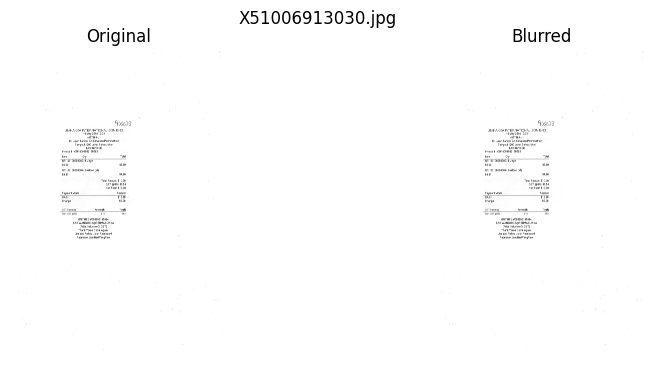

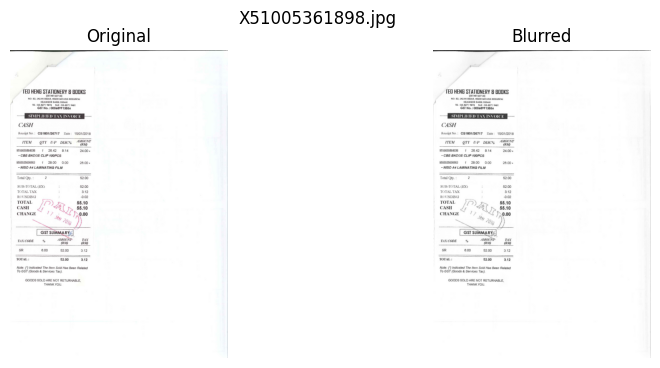

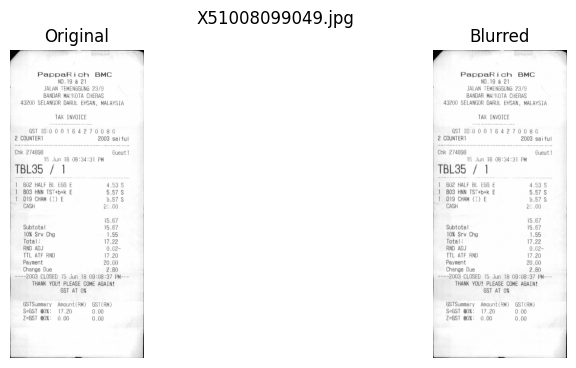

In [152]:
def blur_process(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.GaussianBlur(gray, (3,3), 0)

show_before_after(
    train_img_dir,
    blur_process,
    "Blurred"
)

# ***Edge Detection***

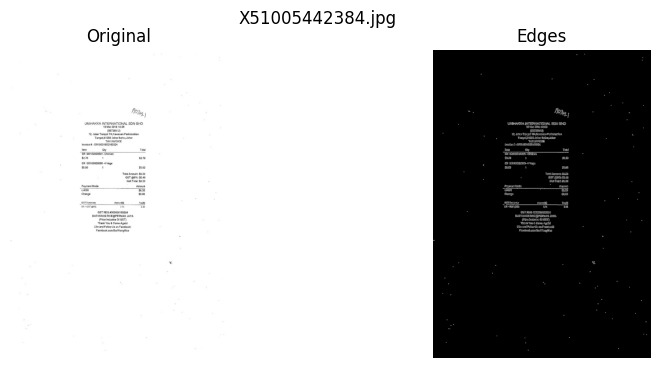

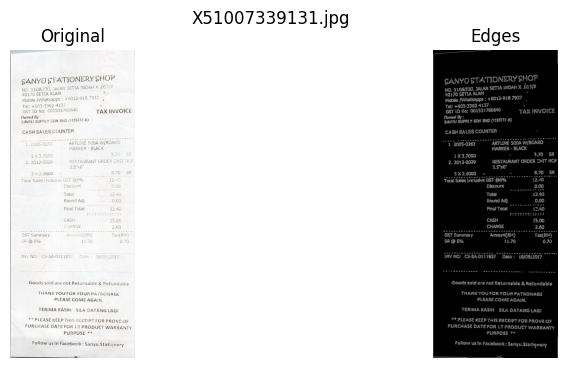

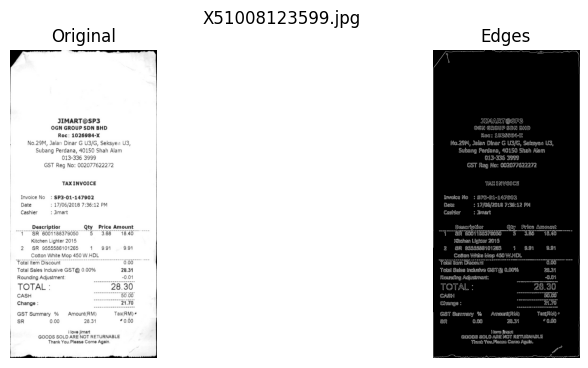

In [153]:
def edge_process(img):

    img = blur_process(img)

    return cv2.Canny(img, 50, 150)

show_before_after(
    train_img_dir,
    edge_process,
    "Edges"
)

# **Contours and perspective transform**

In [154]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import urllib.request

# dataset_path already set above — reconfirm sub-dirs
train_img_dir = os.path.join(dataset_path, "train", "img")
train_box_dir = os.path.join(dataset_path, "train", "box")

test_img_dir = os.path.join(dataset_path, "test", "img")
test_box_dir = os.path.join(dataset_path, "test", "box")


# METHOD 1 — U2Net deep salient object detection

In [155]:
#Download model
def download_model_if_needed():

    model_dir  = "models"
    model_path = os.path.join(model_dir, "u2net_doc.onnx")
    os.makedirs(model_dir, exist_ok=True)

    if not os.path.exists(model_path):
        print("Downloading U2Net document segmentation model...")
        url = "https://github.com/danielgatis/rembg/releases/download/v0.0.0/u2net.onnx"
        urllib.request.urlretrieve(url, model_path)
        print("Download complete.")

    return model_path

In [156]:
def order_points(pts):
    pts    = pts.reshape(4, 2).astype(np.float32)
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    pts    = pts[np.argsort(angles)]
    start  = np.argmin(pts.sum(axis=1))
    pts    = np.roll(pts, -start, axis=0)
    return pts.astype("float32")


In [157]:
def four_point_warp(image, pts):
    rect = order_points(pts)
    tl, tr, br, bl = rect
    w1 = np.linalg.norm(br - bl)
    w2 = np.linalg.norm(tr - tl)
    h1 = np.linalg.norm(tr - br)
    h2 = np.linalg.norm(tl - bl)
    max_w = max(int(w1), int(w2))
    max_h = max(int(h1), int(h2))
    if max_w == 0 or max_h == 0:
        return image
    dst = np.array([
        [0,         0        ],
        [max_w - 1, 0        ],
        [max_w - 1, max_h - 1],
        [0,         max_h - 1],
    ], dtype="float32")
    M      = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_w, max_h))
    avg_w  = (w1 + w2) / 2
    avg_h  = (h1 + h2) / 2
    if avg_w > avg_h * 1.2:
        warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)
    return warped

In [158]:
def border_contour(img):
    h, w = img.shape[:2]
    pad  = 4
    return np.array([
        [pad,     pad    ],
        [w - pad, pad    ],
        [w - pad, h - pad],
        [pad,     h - pad],
    ], dtype=np.float32)

In [159]:
#Take the best quad from binary mask



def quad_from_mask(mask, total_area, img_shape):

    candidates = []
    kernel     = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    mask       = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=4)
    mask       = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=2)

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:3]

    for c in cnts:
        area = cv2.contourArea(c)
        if area < total_area * 0.05:
            continue

        hull = cv2.convexHull(c)
        peri = cv2.arcLength(hull, True)

        for eps in [0.01, 0.02, 0.03, 0.05, 0.08, 0.12]:
            approx = cv2.approxPolyDP(hull, eps * peri, True)
            if len(approx) == 4:
                pts = order_points(approx.reshape(4, 2))
                candidates.append(pts)
                break

        # If we couldn't get 4 points, fit a bounding rect
        if not candidates:
            rect    = cv2.minAreaRect(c)
            box     = cv2.boxPoints(rect)
            pts     = order_points(box)
            candidates.append(pts)

    if not candidates:
        return None

    # Pick candidate with best area coverage
    def score(pts):
        area = cv2.contourArea(pts.reshape(-1, 1, 2).astype(np.int32))
        return abs(area - total_area * 0.6)   # prefer ~60% coverage

    return min(candidates, key=score)

In [160]:
#Runs U2net to make a sailency/foreground mask
def u2net_segment(img_bgr, model_path):

    net = cv2.dnn.readNetFromONNX(model_path)

    h, w    = img_bgr.shape[:2]
    inp_sz  = 320
    blob    = cv2.dnn.blobFromImage(
        img_bgr, 1.0 / 255.0,
        (inp_sz, inp_sz),
        (0.485, 0.456, 0.406),   # ImageNet mean
        swapRB=True, crop=False
    )
    # Normalize std
    blob[0, 0] /= 0.229
    blob[0, 1] /= 0.224
    blob[0, 2] /= 0.225

    net.setInput(blob)
    out    = net.forward()          # shape (1, 1, 320, 320)
    pred   = out[0, 0]              # (320, 320)

    # Normalize to 0-255
    pred   = (pred - pred.min()) / (pred.max() - pred.min() + 1e-6)
    mask   = (pred * 255).astype(np.uint8)
    mask   = cv2.resize(mask, (w, h))

    # Threshold
    _, mask_bin = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask_bin  #return uint8 mask 0-255 in input size


# **#METHOD 2 — Classic CV fallback (multi-strategy)**

In [161]:
#Use it when deep learning fails

def classic_segment(img_res, total_area):

    h, w  = img_res.shape[:2]
    gray  = cv2.cvtColor(img_res, cv2.COLOR_BGR2GRAY)
    masks = []

    #  Heavy-blur with threshold
    for ksize in [31, 51]:
        blurred = cv2.GaussianBlur(gray, (ksize, ksize), 0)
        _, m    = cv2.threshold(blurred, 0, 255,
                                cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        masks.append(m)

    # HSV segmentaion
    hsv      = cv2.cvtColor(img_res, cv2.COLOR_BGR2HSV)
    doc_mask = cv2.inRange(hsv[:,:,1], 0, 60) & \
               cv2.inRange(hsv[:,:,2], 120, 255)
    masks.append(doc_mask)

    # GrabCut
    try:
        mask   = np.zeros((h, w), np.uint8)
        bgd    = np.zeros((1, 65), np.float64)
        fgd    = np.zeros((1, 65), np.float64)
        margin = int(min(h, w) * 0.05)
        rect   = (margin, margin, w - 2*margin, h - 2*margin)
        cv2.grabCut(img_res, mask, rect, bgd, fgd, 5,
                    cv2.GC_INIT_WITH_RECT)
        gc_mask = np.where((mask==2)|(mask==0), 0, 255).astype(np.uint8)
        masks.append(gc_mask)
    except Exception:
        pass

    #Edge-based
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    eq      = clahe.apply(gray)
    blurred = cv2.GaussianBlur(eq, (9, 9), 0)
    otsu, _ = cv2.threshold(blurred, 0, 255,
                            cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edged   = cv2.Canny(blurred, 0.5*otsu, otsu)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    closed  = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel, iterations=5)
    masks.append(closed)

    # Score each mask
    best_mask  = None
    best_score = -1

    for m in masks:
        kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (15,15))
        m_clean = cv2.morphologyEx(m, cv2.MORPH_CLOSE, kernel, iterations=3)
        cnts, _ = cv2.findContours(m_clean, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        c    = max(cnts, key=cv2.contourArea)
        area = cv2.contourArea(c)
        if area < total_area * 0.05:
            continue

        # Rectangularity
        hull      = cv2.convexHull(c)
        hull_area = cv2.contourArea(hull) + 1e-6
        rect_score = area / hull_area        # 1.0 = perfect rectangle
        area_score = area / total_area       # prefer larger

        score = rect_score * 0.5 + area_score * 0.5
        if score > best_score:
            best_score = score
            best_mask  = m_clean

    return best_mask


In [162]:
#Choose which img type we process now

def classify_image(img_res):

    #scan  = no real background (clean scan, screenshot, white border)
    #photo = real photo with background (table, desk, hand-held)

    gray         = cv2.cvtColor(img_res, cv2.COLOR_BGR2GRAY)
    h, w         = gray.shape
    pad_h        = max(h // 12, 8)
    pad_w        = max(w // 12, 8)

    corner_patches = [
        gray[:pad_h,  :pad_w ],  gray[:pad_h,  -pad_w:],
        gray[-pad_h:, :pad_w ],  gray[-pad_h:, -pad_w:],
    ]
    corner_mean  = np.mean([c.mean() for c in corner_patches])
    corner_std   = np.mean([c.std()  for c in corner_patches])
    center_mean  = gray[h//4:3*h//4, w//4:3*w//4].mean()

    hsv         = cv2.cvtColor(img_res, cv2.COLOR_BGR2HSV)
    sat_corners = np.mean([
        hsv[:pad_h,  :pad_w,  1].mean(),
        hsv[:pad_h,  -pad_w:, 1].mean(),
        hsv[-pad_h:, :pad_w,  1].mean(),
        hsv[-pad_h:, -pad_w:, 1].mean(),
    ])

    edged = cv2.Canny(gray, 50, 150)
    t     = max(h, w) // 12
    bm    = np.zeros_like(edged)
    bm[:t,:]=1; bm[-t:,:]=1; bm[:,:t]=1; bm[:,-t:]=1
    border_edge_density = edged[bm == 1].mean()

    b_ch, g_ch, r_ch = cv2.split(img_res)
    is_gray = (np.abs(r_ch.astype(float)-g_ch.astype(float)).mean() < 8 and
               np.abs(r_ch.astype(float)-b_ch.astype(float)).mean() < 8)

    brightness_diff    = abs(corner_mean - center_mean)
    corner_very_bright = corner_mean > 190
    corner_very_flat   = corner_std  < 12

    votes = 0
    if brightness_diff > 15:                              votes += 2
    if corner_std > 18:                                   votes += 2
    if sat_corners > 25:                                  votes += 2
    if border_edge_density > 12:                          votes += 1
    if is_gray:                                           votes -= 3
    if corner_very_bright:                                votes -= 2
    if corner_very_flat:                                  votes -= 1

    return 'photo' if votes >= 3 else 'scan'

In [163]:
def process_and_warp_document(img_path, class_name, model_path=None):
    image = cv2.imread(img_path)
    if image is None:
        print(f"  Could not load: {img_path}")
        return

    orig     = image.copy()
    ratio    = image.shape[0] / 600.0
    img_res  = cv2.resize(image, (int(image.shape[1] / ratio), 600))
    h, w     = img_res.shape[:2]
    total_area = h * w
    img_type = classify_image(img_res)

    print(f"  [{img_type.upper()}] {os.path.basename(img_path)}")

    final_pts = None
    mask_used = None

    # Try deep learning first
    if model_path and os.path.exists(model_path) and img_type == 'photo':
        try:
            mask     = u2net_segment(img_res, model_path)
            mask_used = mask.copy()
            final_pts = quad_from_mask(mask, total_area, img_res.shape)
            if final_pts is not None:
                print("  ✓ U2Net segmentation succeeded")
        except Exception as e:
            print(f"  U2Net failed: {e} — falling back to classic CV")
            final_pts = None

    # Then try Classic CV fallback (or for scans)
    if final_pts is None:
        if img_type == 'scan':
            # For scans: just use the image border directly

            final_pts = border_contour(img_res)
            print("  ✓ Scan detected — using full image border")
        else:
            mask      = classic_segment(img_res, total_area)
            mask_used = mask
            if mask is not None:
                final_pts = quad_from_mask(mask, total_area, img_res.shape)
            if final_pts is None:
                print("  Classic CV failed — using full image border")
                final_pts = border_contour(img_res)

    #warp
    warped = four_point_warp(orig, final_pts * ratio)

    #plot
    ncols = 4 if mask_used is not None else 3
    fig, ax = plt.subplots(1, ncols, figsize=(5*ncols, 6))
    plt.suptitle(f"Scanner: {class_name}  [{img_type}]", fontsize=13)

    ax[0].imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
    ax[0].set_title("Original"); ax[0].axis("off")

    if mask_used is not None:
        ax[1].imshow(mask_used, cmap='gray')
        ax[1].set_title("Segmentation mask"); ax[1].axis("off")
        idx = 2
    else:
        idx = 1

    viz = img_res.copy()
    cv2.drawContours(viz,
                     [final_pts.reshape(-1,1,2).astype(np.int32)],
                     -1, (0,255,0), 3)
    for pt in final_pts:
        cv2.circle(viz, tuple(pt.astype(int)), 8, (0,0,255), -1)
    ax[idx].imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
    ax[idx].set_title("Detected Boundary"); ax[idx].axis("off")

    ax[idx+1].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    ax[idx+1].set_title("Perspective Corrected"); ax[idx+1].axis("off")

    plt.tight_layout()
    plt.show()

Total images: 626

───────────────────────────────────────────────────────
Processing: X00016469612.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469612.jpg
  ✓ Scan detected — using full image border


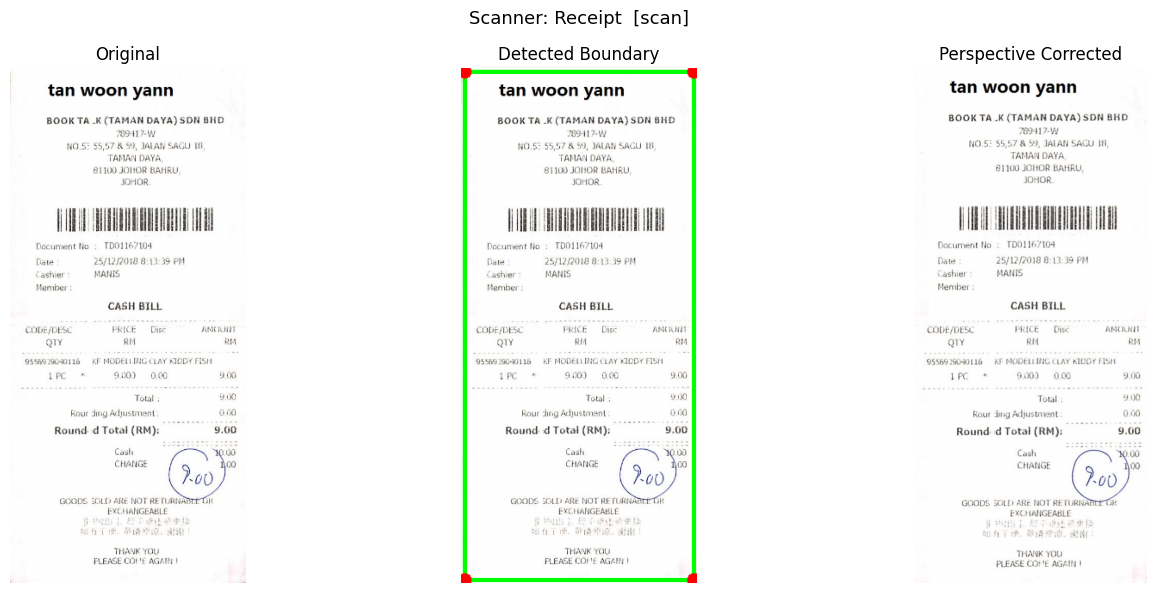


───────────────────────────────────────────────────────
Processing: X00016469619.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469619.jpg
  ✓ Scan detected — using full image border


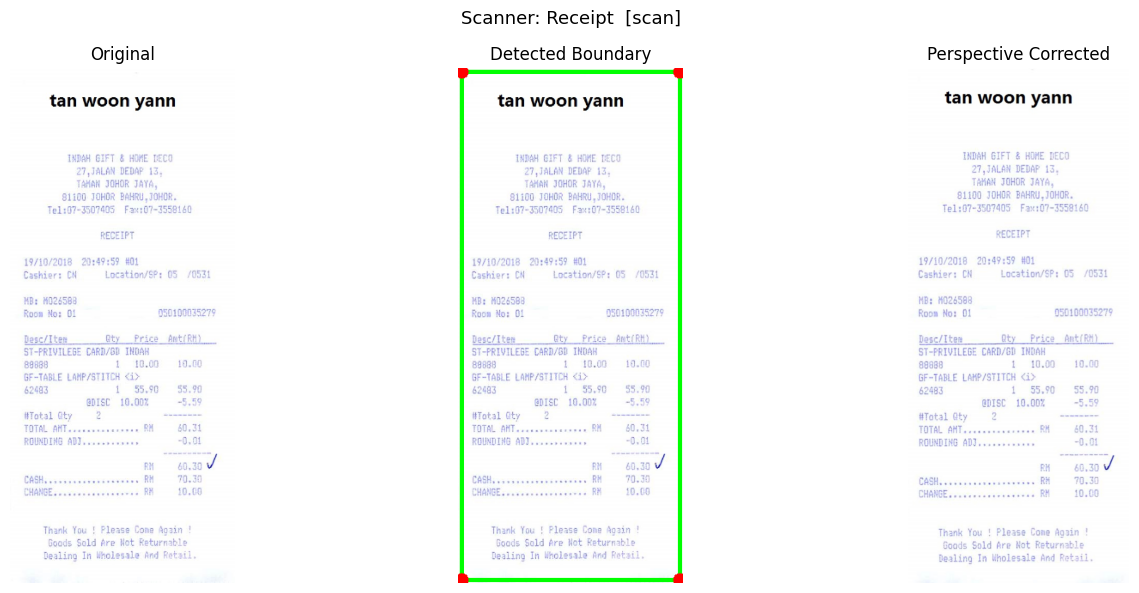


───────────────────────────────────────────────────────
Processing: X00016469620.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469620.jpg
  ✓ Scan detected — using full image border


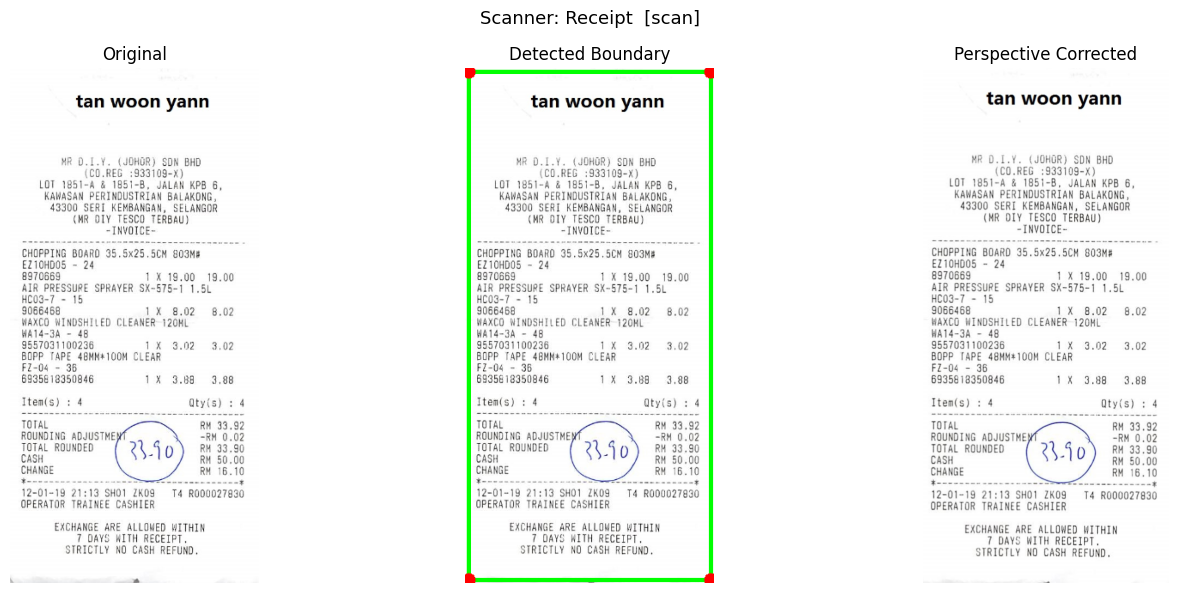


───────────────────────────────────────────────────────
Processing: X00016469622.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469622.jpg
  ✓ Scan detected — using full image border


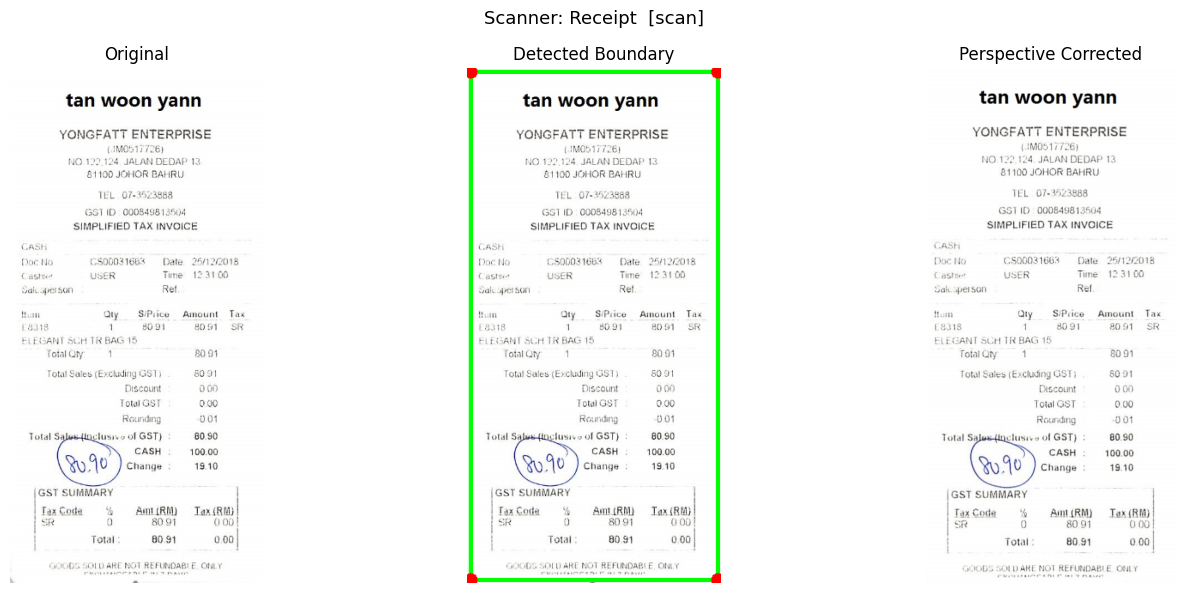


───────────────────────────────────────────────────────
Processing: X00016469623.jpg
───────────────────────────────────────────────────────
  [SCAN] X00016469623.jpg
  ✓ Scan detected — using full image border


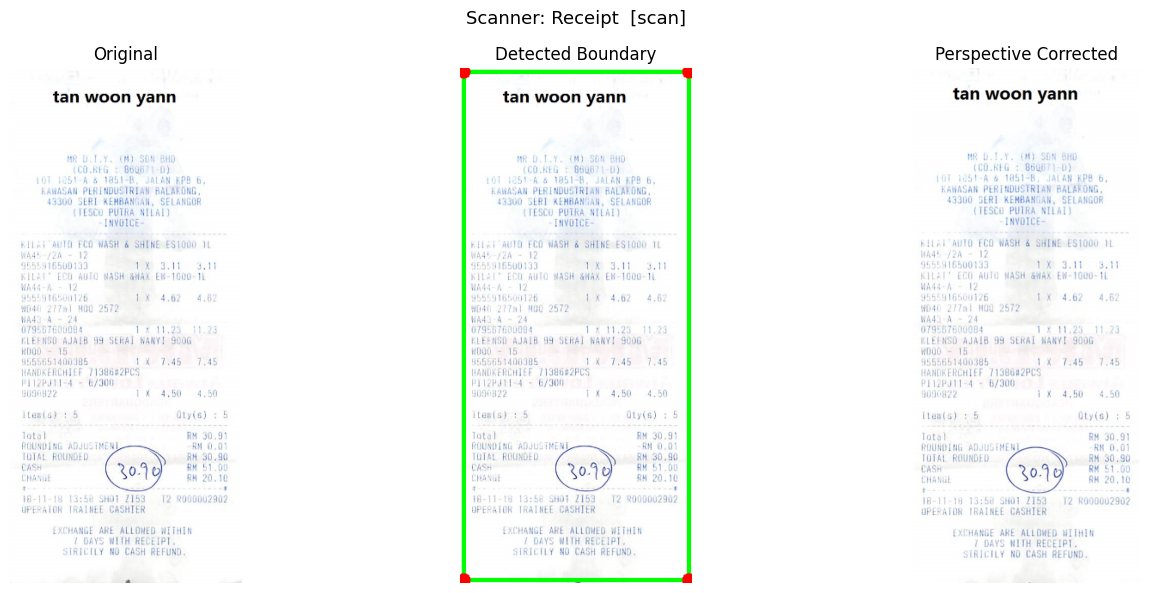

In [164]:
# Instead of download_model_if_needed()
model_path = "/kaggle/input/u2net-onnx-weights/u2net.onnx"

# Image directory (already set above)
imgs = sorted([
    f for f in os.listdir(train_img_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
])

print(f"Total images: {len(imgs)}")

# Process first 5 images
for img_name in imgs[:5]:

    img_path = os.path.join(train_img_dir, img_name)

    print(f"\n{'─'*55}")
    print(f"Processing: {img_name}")
    print(f"{'─'*55}")

    process_and_warp_document(
        img_path,
        "Receipt",
        model_path=model_path
    )


# **Image Enhancement**

In [165]:
import random
import cv2
import os
import matplotlib.pyplot as plt

def show_enhanced_images(dataset_path, num_images=2):
    # SROIE structure: dataset_path/{train,test}/img/*.jpg
    splits = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d))]

    for split in splits:
        img_dir = os.path.join(dataset_path, split, "img")
        if not os.path.isdir(img_dir):
            continue  # skip non-image folders (e.g. layoutlm-base-uncased)

        images = [img for img in os.listdir(img_dir)
                  if img.lower().endswith((".png", ".jpg", ".jpeg"))]

        if not images:
            continue

        sample_images = random.sample(images, min(num_images, len(images)))

        fig, axes = plt.subplots(len(sample_images), 2,
                                 figsize=(12, 5 * len(sample_images)))
        fig.suptitle(f"Split: {split}", fontsize=18, fontweight='bold')

        if len(sample_images) == 1:
            axes = np.expand_dims(axes, axis=0)

        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(img_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            enhanced = enhance_image(img)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[i, 0].imshow(img_rgb)
            axes[i, 0].set_title("Original", fontsize=12)
            axes[i, 0].axis("off")

            axes[i, 1].imshow(enhanced, cmap='gray')
            axes[i, 1].set_title("Enhanced (Adaptive Threshold)", fontsize=12)
            axes[i, 1].axis("off")

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()


In [166]:
import cv2
import numpy as np

def enhance_image(image: np.ndarray) -> np.ndarray:
    # 1. Grayscale only if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    # 2. Light denoise ONLY if needed
    noise_est = cv2.Laplacian(gray, cv2.CV_64F).var()
    if noise_est < 30:  # only very noisy images
        gray = cv2.fastNlMeansDenoising(gray, None, h=6)

    # 3. No resizing unless extremely small (prevents blur)
    h, w = gray.shape
    if max(h, w) < 600:
        gray = cv2.resize(gray, None, fx=1.3, fy=1.3, interpolation=cv2.INTER_CUBIC)

    # 4. Mild contrast only
    clahe = cv2.createCLAHE(clipLimit=1.8, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # 5. Adaptive threshold directly (no heavy preprocessing chain)
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31, 10
    )

    # 6. Polarity fix
    if np.mean(binary) < 127:
        binary = cv2.bitwise_not(binary)

    return binary

print('✓ enhance_image (optimised) defined.')


✓ enhance_image (optimised) defined.


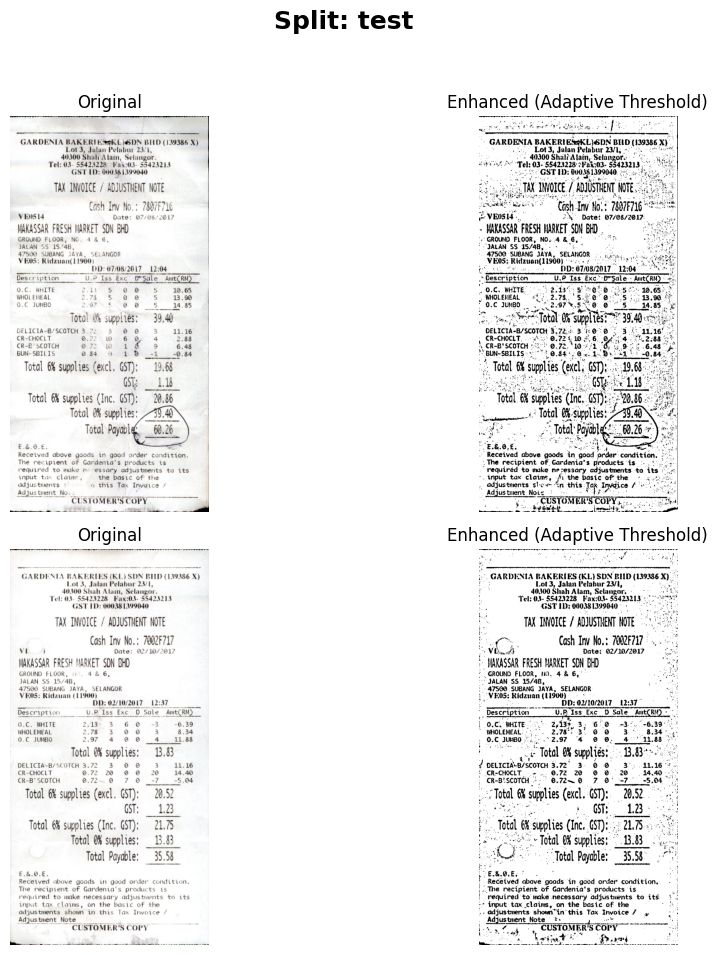

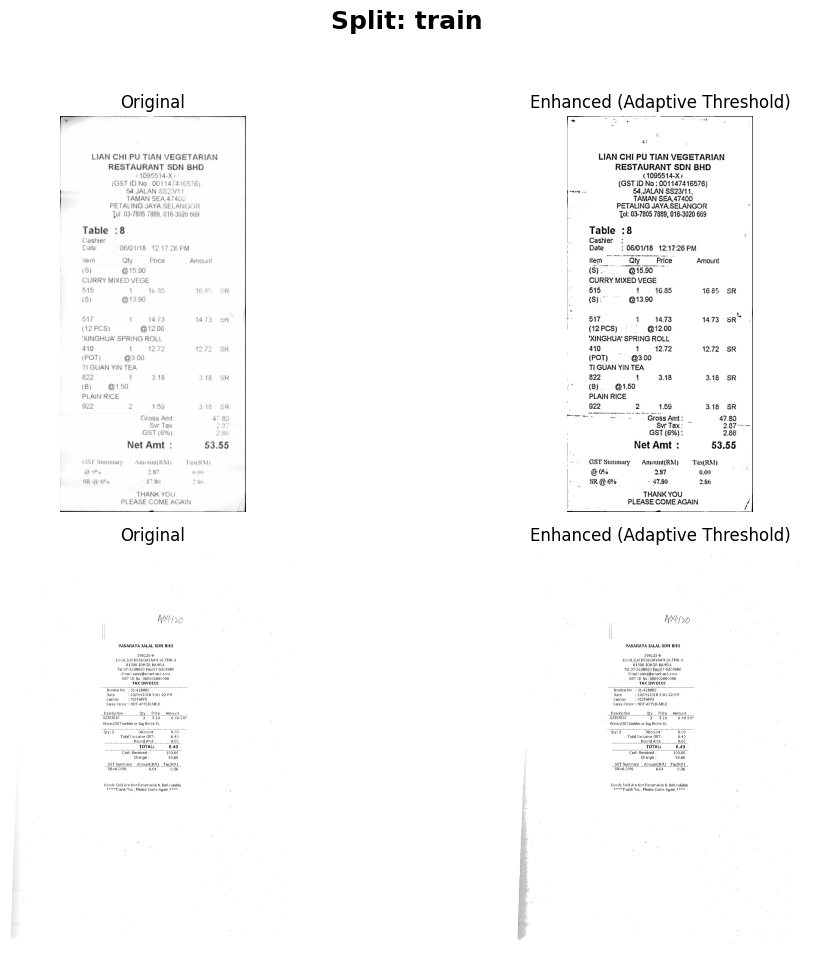

In [167]:
# Run the visualization
show_enhanced_images(dataset_path, num_images=2)

# ***Segmentation: Separate Text from Background***

## Overview

After the document boundary is detected and the perspective is corrected, we apply **text-background segmentation** to produce a clean, binarised image where ink pixels are black and the page is white.  

Three complementary strategies are implemented and compared:

| # | Method | When it shines |
|---|--------|----------------|
| 1 | **Adaptive Thresholding** | Uneven lighting, shadows |
| 2 | **Sauvola Local Thresholding** | Low-contrast or faded text |
| 3 | **Morphological Top-Hat + Otsu** | Wrinkled / noisy backgrounds |

In [168]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, random

# ── helpers already defined above (enhance_image, four_point_warp, etc.) ──

In [169]:
# ─────────────────────────────────────────────────────────────────────────
# STRATEGY 1 — Adaptive Gaussian Thresholding
# Best for: uneven illumination, shadows, phone-camera shots
# ─────────────────────────────────────────────────────────────────────────
def segment_adaptive(gray: np.ndarray,
                     block_size: int = 31,
                     C: int = 10) -> np.ndarray:
    """
    Binarise a grayscale document image with adaptive Gaussian thresholding.

    Parameters
    ----------
    gray       : uint8 grayscale image
    block_size : size of the local neighbourhood (must be odd, >=3)
    C          : constant subtracted from the weighted mean

    Returns
    -------
    binary : uint8 image (0 = text / ink,  255 = background / paper)
    """
    # Denoise while keeping edges sharp
    denoised = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

    binary = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size, C
    )
    return binary


# ─────────────────────────────────────────────────────────────────────────
# STRATEGY 2 — Sauvola Local Thresholding
# Best for: low-contrast, faded, or water-damaged text
# ─────────────────────────────────────────────────────────────────────────
def _sauvola_threshold(gray: np.ndarray,
                        window: int = 51,
                        k: float = 0.2,
                        R: float = 128.0) -> np.ndarray:
    """
    Pure-NumPy Sauvola binarisation.

    T(x,y) = mean * (1 + k * (std/R - 1))

    Parameters
    ----------
    gray   : uint8 grayscale image
    window : local window side length (must be odd)
    k      : sensitivity  (0.1 – 0.5; higher → more aggressive)
    R      : dynamic-range constant (128 works for 8-bit images)

    Returns
    -------
    binary : uint8 image (0 = text, 255 = background)
    """
    img = gray.astype(np.float64)
    pad = window // 2
    img_pad = np.pad(img, pad, mode='reflect')

    # Compute local mean and variance via integral images
    integral  = cv2.integral(img_pad)
    integral2 = cv2.integral(img_pad ** 2)

    h, w = gray.shape
    # Slice corners for the sliding sum
    tl = integral[:h,   :w  ]
    tr = integral[:h,   window:w+window]
    bl = integral[window:h+window, :w  ]
    br = integral[window:h+window, window:w+window]

    tl2 = integral2[:h,   :w  ]
    tr2 = integral2[:h,   window:w+window]
    bl2 = integral2[window:h+window, :w  ]
    br2 = integral2[window:h+window, window:w+window]

    N    = window * window
    mean = (br - bl - tr + tl) / N
    sq   = (br2 - bl2 - tr2 + tl2) / N
    std  = np.sqrt(np.maximum(sq - mean**2, 0))

    threshold = mean * (1.0 + k * (std / R - 1.0))
    binary    = np.where(img < threshold, 0, 255).astype(np.uint8)
    return binary


def segment_sauvola(gray: np.ndarray,
                    window: int = 51,
                    k: float = 0.2) -> np.ndarray:
    """
    Sauvola segmentation with a light denoising pre-pass.
    Returns uint8 binary (0=text, 255=background).
    """
    denoised = cv2.GaussianBlur(gray, (3, 3), 0)
    return _sauvola_threshold(denoised, window=window, k=k)


# ─────────────────────────────────────────────────────────────────────────
# STRATEGY 3 — Morphological Top-Hat + Otsu
# Best for: wrinkled pages, non-uniform paper texture, noisy backgrounds
# ─────────────────────────────────────────────────────────────────────────
def segment_tophat_otsu(gray: np.ndarray,
                         kernel_size: int = 25) -> np.ndarray:
    """
    Morphological top-hat transform to flatten background, then Otsu.

    Top-hat = image - morphological_opening(image)
    This removes large-scale background variation, leaving only fine
    bright structures (text strokes on a lighter background).

    Parameters
    ----------
    gray        : uint8 grayscale image
    kernel_size : structuring element size (should be > the widest stroke)

    Returns
    -------
    binary : uint8 image (0 = text, 255 = background)
    """
    kernel  = cv2.getStructuringElement(
        cv2.MORPH_RECT, (kernel_size, kernel_size))

    # Black-hat highlights dark objects (ink) on a bright background
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

    # Otsu on the black-hat residual
    _, binary_ink = cv2.threshold(
        blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Invert so ink=0, background=255 (same convention as other methods)
    binary = cv2.bitwise_not(binary_ink)
    return binary


# ─────────────────────────────────────────────────────────────────────────
# AUTO-SELECT: pick the best strategy per image
# ─────────────────────────────────────────────────────────────────────────
def auto_segment(gray: np.ndarray) -> tuple[np.ndarray, str]:
    """
    Automatically choose and apply the best segmentation strategy.

    Heuristic
    ---------
    - High std-dev of local means  → uneven lighting  → Adaptive
    - Low global contrast           → faded text       → Sauvola
    - Otherwise                                        → Top-Hat + Otsu

    Returns
    -------
    (binary, method_name)
    """
    # Measure illumination unevenness via std of block means
    h, w = gray.shape
    b    = max(h // 8, 16)
    block_means = []
    for r in range(0, h - b, b):
        for c in range(0, w - b, b):
            block_means.append(gray[r:r+b, c:c+b].mean())
    illumination_std = np.std(block_means)

    global_contrast  = gray.max() - gray.min()

    if illumination_std > 25:
        return segment_adaptive(gray), 'Adaptive Thresholding'
    elif global_contrast < 120:
        return segment_sauvola(gray), 'Sauvola'
    else:
        return segment_tophat_otsu(gray), 'Top-Hat + Otsu'


print('✓ Segmentation functions defined.')

✓ Segmentation functions defined.


In [170]:
def visualise_segmentation(img_bgr: np.ndarray,
                            title: str = '') -> None:
    """
    Display the original image next to all three segmentation results
    plus the auto-selected output.

    Parameters
    ----------
    img_bgr : colour document image (BGR, uint8)
    title   : optional super-title for the figure
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    results = [
        ('Original',              cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), False),
        ('Adaptive\nThresholding', segment_adaptive(gray),                  True),
        ('Sauvola\nLocal Thresh.', segment_sauvola(gray),                   True),
        ('Top-Hat\n+ Otsu',        segment_tophat_otsu(gray),               True),
    ]

    auto_bin, auto_name = auto_segment(gray)
    results.append((f'Auto-Selected\n({auto_name})', auto_bin, True))

    fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 6))
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, (label, img, is_gray) in zip(axes, results):
        ax.imshow(img, cmap='gray' if is_gray else None)
        ax.set_title(label, fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print('✓ Visualisation helper defined.')

✓ Visualisation helper defined.


In [171]:
def full_pipeline(img_path: str,
                   model_path: str = None,
                   show_steps: bool = True) -> np.ndarray:
    """
    End-to-end document scanner pipeline:
      1. Load image
      2. Detect document boundary (U2Net → Classic CV → border fallback)
      3. Perspective-correct the document
      4. Segment text from background (auto-selects best method)

    Parameters
    ----------
    img_path   : path to the input image
    model_path : path to u2net.onnx (optional)
    show_steps : if True, display intermediate results

    Returns
    -------
    clean_bin : binarised document image (uint8, 0=text, 255=bg)
    """
    image = cv2.imread(img_path)
    if image is None:
        raise FileNotFoundError(f'Cannot load: {img_path}')

    # ── Step 1–3: boundary + warp (reuse existing functions) ──────────────
    orig      = image.copy()
    ratio     = image.shape[0] / 600.0
    img_res   = cv2.resize(image, (int(image.shape[1] / ratio), 600))
    h, w      = img_res.shape[:2]
    total_area = h * w
    img_type  = classify_image(img_res)

    final_pts = None
    if model_path and os.path.exists(model_path) and img_type == 'photo':
        try:
            mask      = u2net_segment(img_res, model_path)
            final_pts = quad_from_mask(mask, total_area, img_res.shape)
        except Exception:
            final_pts = None

    if final_pts is None:
        if img_type == 'scan':
            final_pts = border_contour(img_res)
        else:
            mask      = classic_segment(img_res, total_area)
            final_pts = quad_from_mask(mask, total_area, img_res.shape) \
                        if mask is not None else border_contour(img_res)

    warped = four_point_warp(orig, final_pts * ratio)

    # ── Step 4: text-background segmentation ──────────────────────────────
    gray_warped          = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    clean_bin, seg_name  = auto_segment(gray_warped)

    if show_steps:
        fig, axes = plt.subplots(1, 4, figsize=(20, 6))
        fig.suptitle(
            f'{os.path.basename(img_path)}  [{img_type}]  '
            f'segmentation: {seg_name}',
            fontsize=12, fontweight='bold'
        )

        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original'); axes[0].axis('off')

        axes[1].imshow(cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f'Resized [{img_type}]'); axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Perspective Corrected'); axes[2].axis('off')

        axes[3].imshow(clean_bin, cmap='gray')
        axes[3].set_title(f'Text Segmented\n({seg_name})'); axes[3].axis('off')

        plt.tight_layout()
        plt.show()

    return clean_bin


print('✓ Full pipeline with segmentation defined.')

✓ Full pipeline with segmentation defined.



Processing: Train Images/X00016469612.jpg


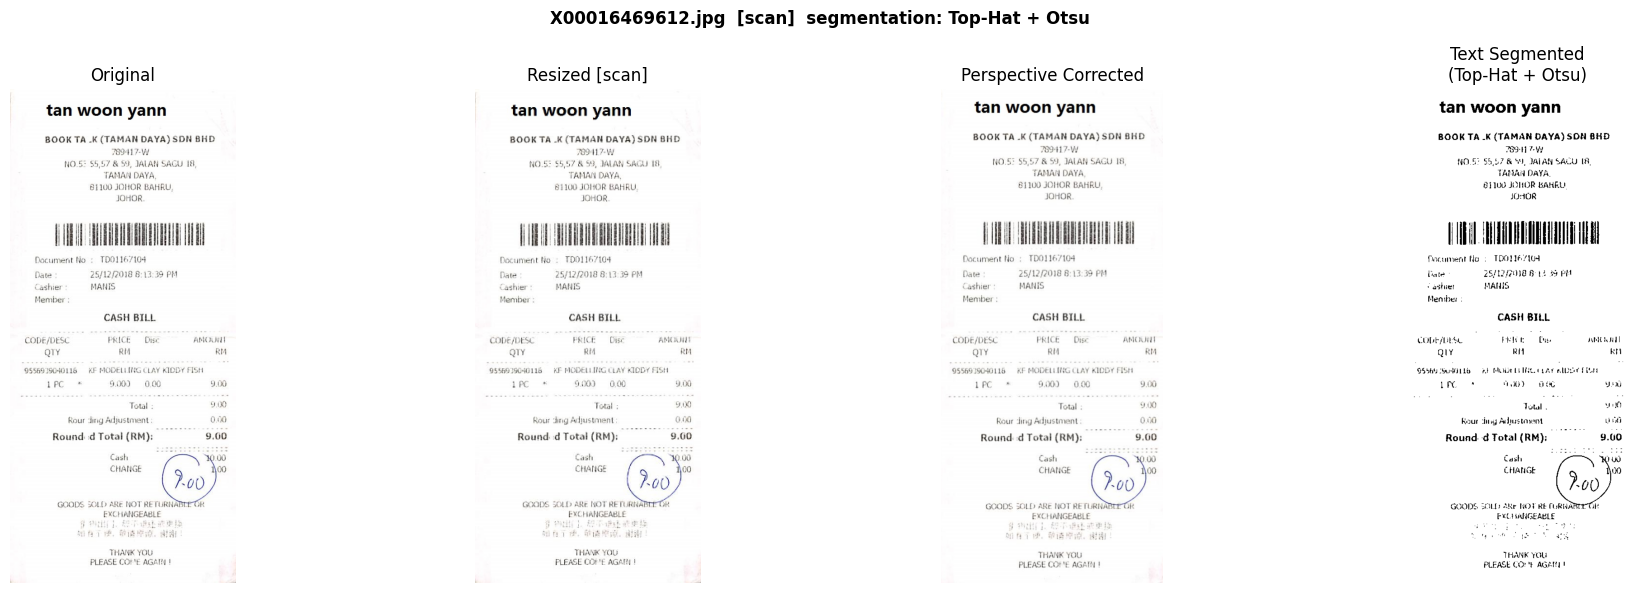

  Output shape: (999, 449),  text pixels: 24,143

Processing: Test Images/X00016469670.jpg


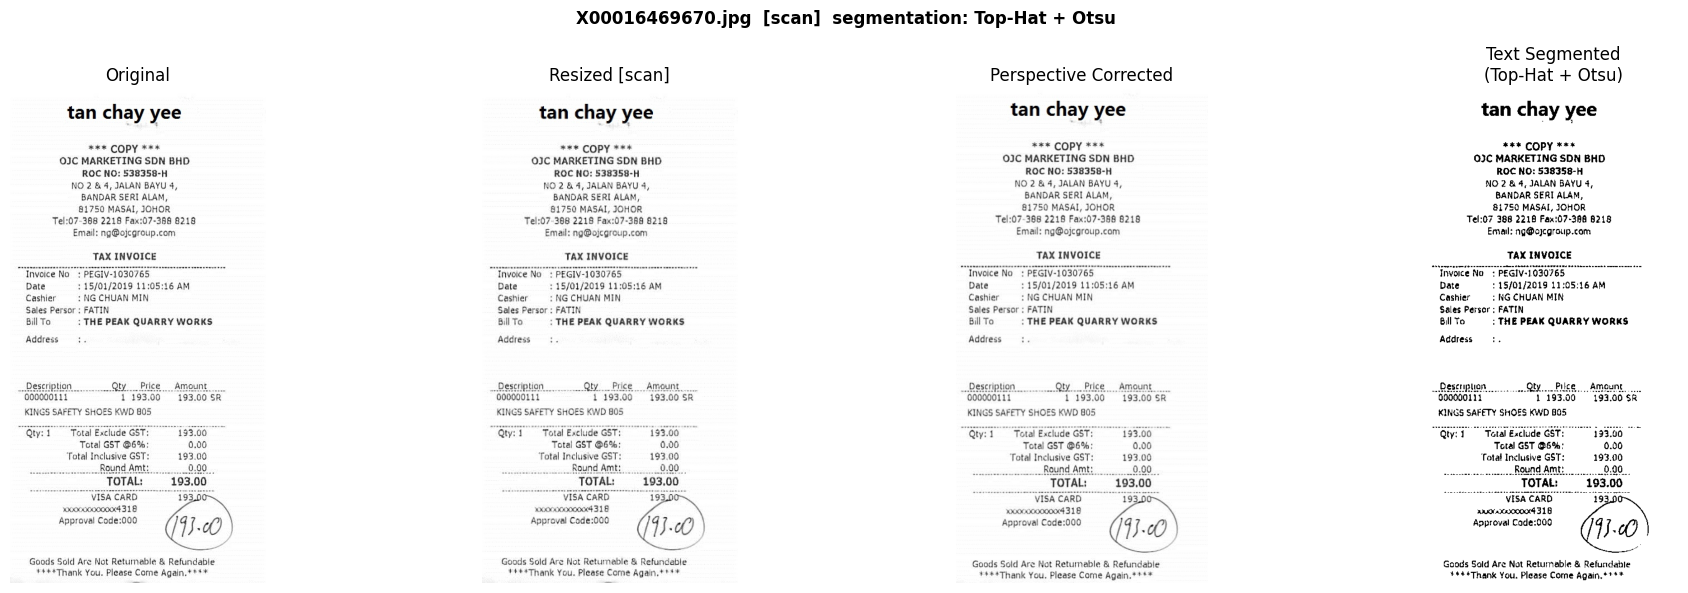

  Output shape: (882, 449),  text pixels: 30,566


In [172]:
categories = {
    "Train Images": train_img_dir,
    "Test Images":  test_img_dir,
}

for cls, cls_path in categories.items():
    imgs = sorted([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
    ])
    for img_name in imgs[:1]:
        img_path = os.path.join(cls_path, img_name)
        print(f'\nProcessing: {cls}/{img_name}')
        clean = full_pipeline(img_path, model_path=model_path, show_steps=True)
        print(f'  Output shape: {clean.shape},  '
              f'text pixels: {(clean == 0).sum():,}')

In [173]:
# ─────────────────────────────────────────────────────────────────────────
# LETTER-BY-LETTER SEGMENTATION
# Extracts individual character bounding boxes from a binarised document
# Pipeline: binary image → find contours → filter by size → sort L→R, T→B
# ─────────────────────────────────────────────────────────────────────────

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os


# ── 1. LINE DETECTION ─────────────────────────────────────────────────────
def detect_text_lines(binary_img: np.ndarray,
                       dilation_h: int = 5,
                       dilation_w: int = 30) -> list[tuple]:
    """
    Group character contours into text lines using horizontal dilation.

    Returns list of (y_start, y_end, x_start, x_end) row bounding boxes,
    sorted top-to-bottom.
    """
    inv = cv2.bitwise_not(binary_img)  # ink = white on black
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (dilation_w, dilation_h))
    dilated = cv2.dilate(inv, kernel, iterations=1)

    cnts, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)
    lines = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        lines.append((y, y + h, x, x + w))

    lines.sort(key=lambda b: b[0])   # top-to-bottom
    return lines


# ── 2. CHARACTER CONTOUR EXTRACTION ───────────────────────────────────────
def extract_character_boxes(binary_img: np.ndarray,
                              min_area: int = 20,
                              min_h: int = 8,
                              max_h_ratio: float = 0.9,
                              min_aspect: float = 0.05,
                              max_aspect: float = 5.0) -> list[tuple]:
    """
    Find bounding boxes for individual characters.

    Parameters
    ----------
    binary_img    : uint8 (0 = ink, 255 = paper)
    min_area      : discard tiny noise blobs (px²)
    min_h         : minimum character height (px)
    max_h_ratio   : max height as fraction of image height (filters rules/borders)
    min_aspect    : min width/height ratio
    max_aspect    : max width/height ratio

    Returns
    -------
    List of (x, y, w, h) sorted left→right, top→bottom
    """
    img_h, img_w = binary_img.shape[:2]
    inv = cv2.bitwise_not(binary_img)   # ink = 255

    cnts, _ = cv2.findContours(inv, cv2.RETR_EXTERNAL,
                                cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        area   = w * h
        aspect = w / (h + 1e-6)

        if (area   >= min_area and
            h      >= min_h and
            h      <= img_h * max_h_ratio and
            aspect >= min_aspect and
            aspect <= max_aspect):
            boxes.append((x, y, w, h))

    # Sort: top-to-bottom, then left-to-right within each line
    boxes.sort(key=lambda b: (b[1], b[0]))
    return boxes


# ── 3. LINE-AWARE CHARACTER ORDERING ──────────────────────────────────────
def assign_to_lines(boxes: list[tuple],
                     line_overlap_thresh: float = 0.5) -> list[list[tuple]]:
    """
    Group character bounding boxes into text lines.

    Uses vertical overlap: two boxes belong to the same line when their
    vertical intersection / their average height > line_overlap_thresh.

    Returns list of lines, each line a list of (x, y, w, h) sorted L→R.
    """
    if not boxes:
        return []

    lines: list[list[tuple]] = []

    for box in sorted(boxes, key=lambda b: b[1]):   # top-down
        x, y, w, h = box
        placed = False
        for line in lines:
            # Representative box of the line
            rx, ry, rw, rh = line[0]
            overlap  = min(y + h, ry + rh) - max(y, ry)
            avg_h    = (h + rh) / 2
            if overlap / avg_h > line_overlap_thresh:
                line.append(box)
                placed = True
                break
        if not placed:
            lines.append([box])

    # Sort each line left-to-right
    for line in lines:
        line.sort(key=lambda b: b[0])

    return lines


# ── 4. CROP INDIVIDUAL CHARACTERS ─────────────────────────────────────────
def crop_characters(binary_img: np.ndarray,
                     boxes: list[tuple],
                     pad: int = 2) -> list[np.ndarray]:
    """
    Crop each character from the binary image with optional padding.

    Returns list of uint8 grayscale character patches.
    """
    h_img, w_img = binary_img.shape[:2]
    crops = []
    for (x, y, w, h) in boxes:
        x1 = max(x - pad, 0)
        y1 = max(y - pad, 0)
        x2 = min(x + w + pad, w_img)
        y2 = min(y + h + pad, h_img)
        crops.append(binary_img[y1:y2, x1:x2])
    return crops


# ── 5. VISUALISATION ──────────────────────────────────────────────────────
def visualise_character_segmentation(binary_img: np.ndarray,
                                      boxes: list[tuple],
                                      title: str = '',
                                      max_chars_shown: int = 60) -> None:
    """
    Draw bounding boxes on the document image and show a grid of crops.
    """
    # Panel 1: annotated document
    vis = cv2.cvtColor(binary_img, cv2.COLOR_GRAY2RGB)
    for i, (x, y, w, h) in enumerate(boxes):
        color = (220, 50, 50)
        cv2.rectangle(vis, (x, y), (x + w, y + h), color, 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                              gridspec_kw={'width_ratios': [2, 3]})
    if title:
        fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].imshow(vis)
    axes[0].set_title(f'Character Bounding Boxes  ({len(boxes)} detected)')
    axes[0].axis('off')

    # Panel 2: character grid
    crops = crop_characters(binary_img, boxes[:max_chars_shown])
    n = len(crops)
    if n == 0:
        axes[1].text(0.5, 0.5, 'No characters found',
                     ha='center', va='center', transform=axes[1].transAxes)
        axes[1].axis('off')
    else:
        cols = min(n, 20)
        rows = (n + cols - 1) // cols
        grid_h = max(c.shape[0] for c in crops)
        grid_w = max(c.shape[1] for c in crops)

        canvas = np.ones((rows * (grid_h + 2), cols * (grid_w + 2)),
                         dtype=np.uint8) * 200

        for idx, crop in enumerate(crops):
            r, c = divmod(idx, cols)
            y0 = r * (grid_h + 2) + 1
            x0 = c * (grid_w + 2) + 1
            ch, cw = crop.shape[:2]
            canvas[y0:y0 + ch, x0:x0 + cw] = crop

        axes[1].imshow(canvas, cmap='gray', vmin=0, vmax=255)
        axes[1].set_title(
            f'First {n} character crops  (sorted L→R, T→B)')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()


# ── 6. FULL LETTER SEGMENTATION PIPELINE ──────────────────────────────────
def segment_letters(binary_img: np.ndarray,
                     show: bool = True,
                     title: str = '') -> dict:
    """
    Full letter-segmentation pipeline on a binarised document image.

    Parameters
    ----------
    binary_img : uint8 (0 = ink, 255 = paper) — output of auto_segment()
    show       : display annotated figure
    title      : figure title

    Returns
    -------
    dict with keys:
        'boxes'   : list of (x, y, w, h) for all characters
        'lines'   : list of lines, each a list of (x, y, w, h)
        'crops'   : list of individual character image patches
        'n_chars' : total character count
    """
    boxes = extract_character_boxes(binary_img)
    lines = assign_to_lines(boxes)
    crops = crop_characters(binary_img, boxes)

    if show:
        visualise_character_segmentation(binary_img, boxes, title=title)
        print(f'  Lines detected : {len(lines)}')
        print(f'  Characters     : {len(boxes)}')
        for i, line in enumerate(lines):
            print(f'    Line {i+1:2d}: {len(line):3d} chars')

    return {
        'boxes':   boxes,
        'lines':   lines,
        'crops':   crops,
        'n_chars': len(boxes),
    }


print('✓ Letter segmentation functions defined.')

✓ Letter segmentation functions defined.



════════════════════════════════════════════════════════════
Category: Train Images  (first 2 images)
════════════════════════════════════════════════════════════


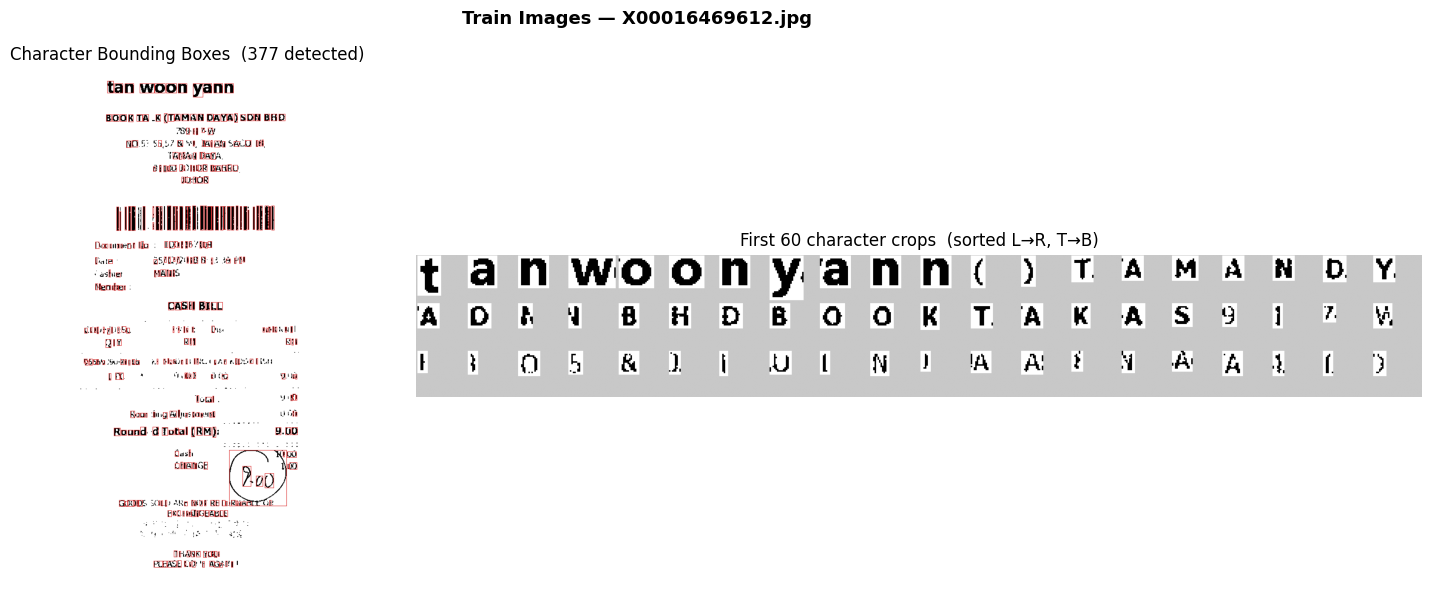

  Lines detected : 29
  Characters     : 377
    Line  1:  11 chars
    Line  2:  25 chars
    Line  3:   5 chars
    Line  4:  15 chars
    Line  5:   9 chars
    Line  6:  18 chars
    Line  7:   6 chars
    Line  8:  35 chars
    Line  9:   1 chars
    Line 10:  22 chars
    Line 11:  16 chars
    Line 12:   8 chars
    Line 13:   9 chars
    Line 14:   9 chars
    Line 15:  23 chars
    Line 16:   9 chars
    Line 17:  26 chars
    Line 18:  12 chars
    Line 19:   6 chars
    Line 20:  16 chars
    Line 21:  18 chars
    Line 22:   4 chars
    Line 23:   2 chars
    Line 24:   9 chars
    Line 25:   2 chars
    Line 26:  24 chars
    Line 27:  14 chars
    Line 28:  10 chars
    Line 29:  13 chars


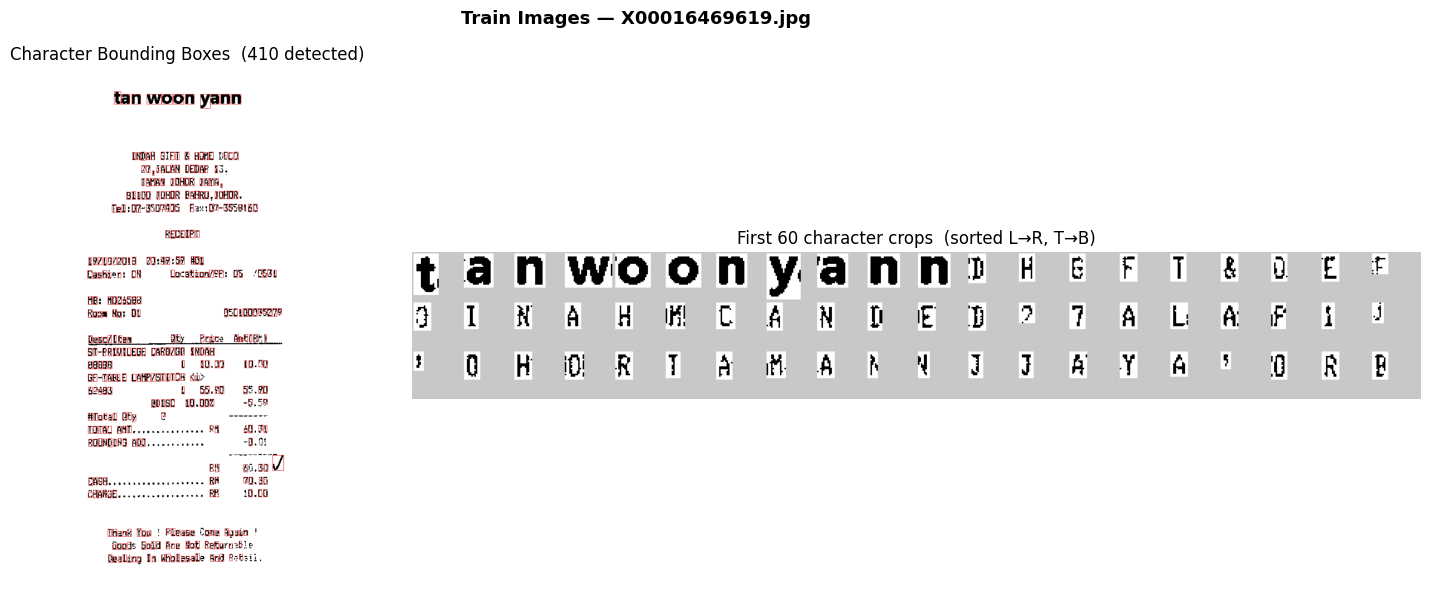

  Lines detected : 28
  Characters     : 410
    Line  1:  11 chars
    Line  2:  16 chars
    Line  3:  13 chars
    Line  4:   1 chars
    Line  5:  15 chars
    Line  6:   1 chars
    Line  7:  20 chars
    Line  8:  20 chars
    Line  9:   7 chars
    Line 10:  19 chars
    Line 11:  24 chars
    Line 12:   9 chars
    Line 13:  19 chars
    Line 14:  22 chars
    Line 15:  24 chars
    Line 16:  14 chars
    Line 17:  20 chars
    Line 18:  13 chars
    Line 19:  12 chars
    Line 20:  10 chars
    Line 21:  14 chars
    Line 22:  12 chars
    Line 23:   6 chars
    Line 24:  10 chars
    Line 25:  12 chars
    Line 26:  23 chars
    Line 27:  21 chars
    Line 28:  22 chars

════════════════════════════════════════════════════════════
Category: Test Images  (first 2 images)
════════════════════════════════════════════════════════════


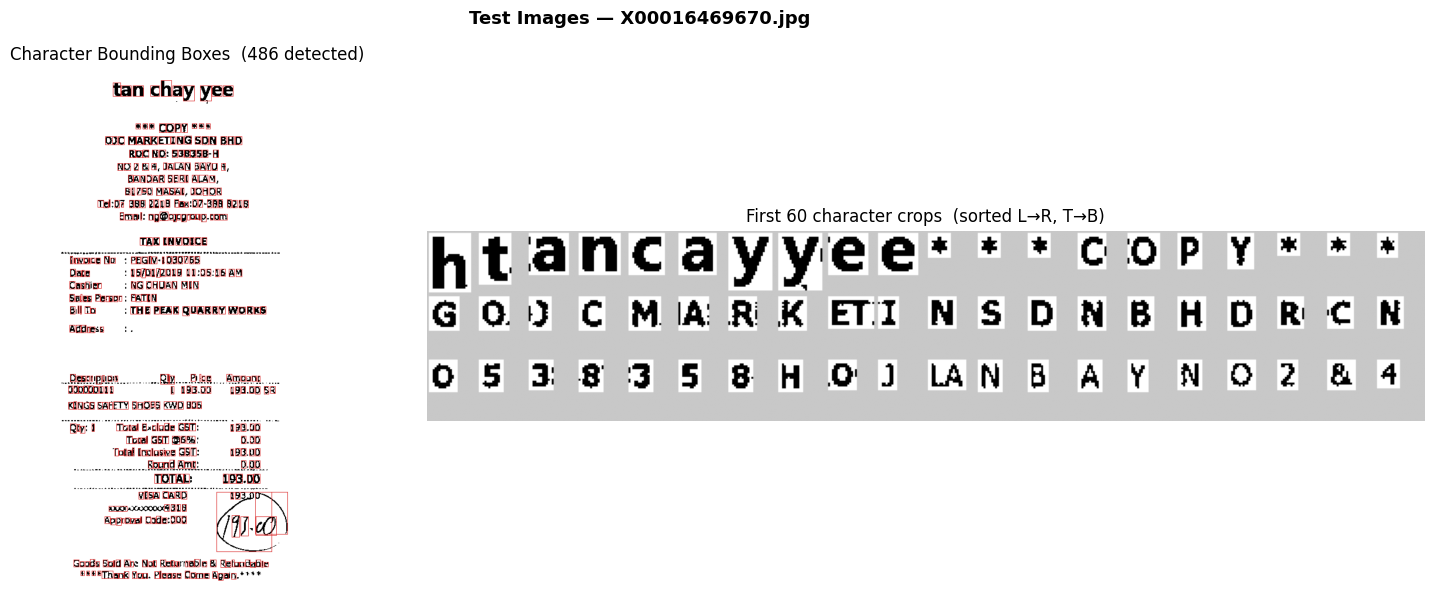

  Lines detected : 31
  Characters     : 486
    Line  1:  10 chars
    Line  2:  10 chars
    Line  3:  17 chars
    Line  4:  12 chars
    Line  5:  14 chars
    Line  6:  13 chars
    Line  7:  15 chars
    Line  8:  24 chars
    Line  9:  19 chars
    Line 10:  10 chars
    Line 11:  22 chars
    Line 12:  22 chars
    Line 13:  17 chars
    Line 14:  16 chars
    Line 15:  22 chars
    Line 16:   6 chars
    Line 17:  22 chars
    Line 18:  22 chars
    Line 19:  19 chars
    Line 20:  23 chars
    Line 21:  14 chars
    Line 22:  22 chars
    Line 23:  11 chars
    Line 24:  10 chars
    Line 25:  10 chars
    Line 26:   3 chars
    Line 27:   5 chars
    Line 28:  17 chars
    Line 29:  34 chars
    Line 30:  12 chars
    Line 31:  13 chars


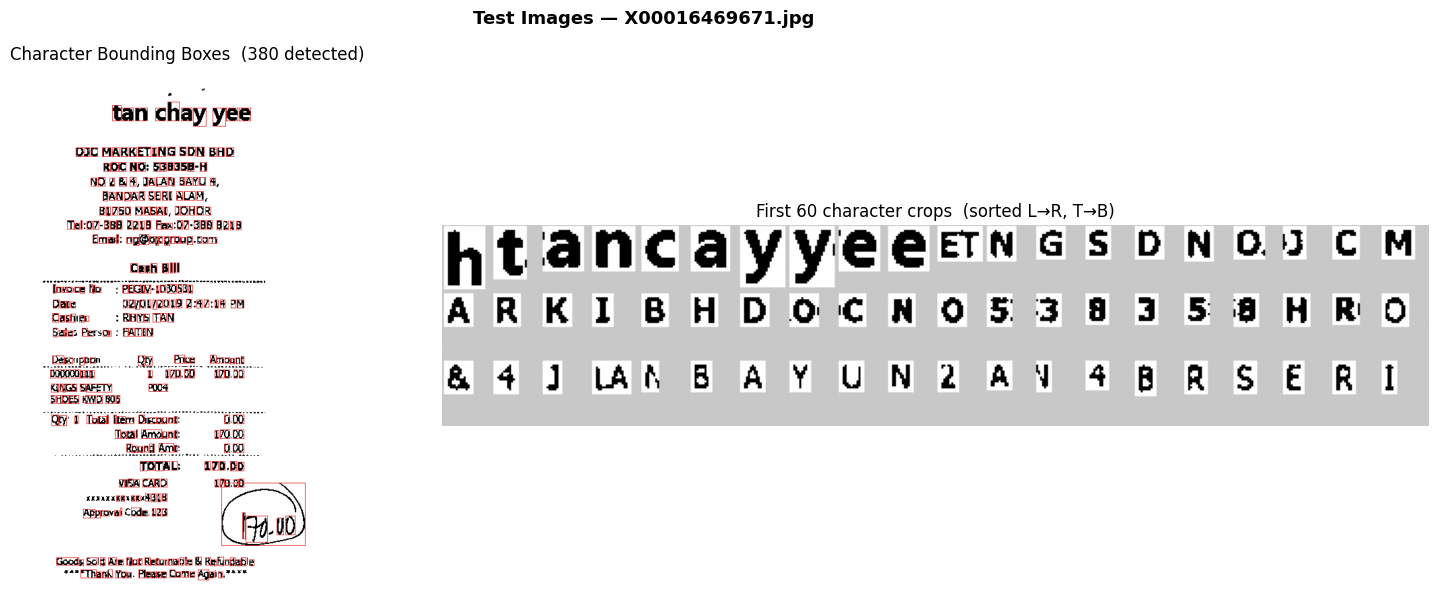

  Lines detected : 28
  Characters     : 380
    Line  1:  10 chars
    Line  2:  17 chars
    Line  3:  12 chars
    Line  4:  15 chars
    Line  5:  13 chars
    Line  6:  15 chars
    Line  7:  24 chars
    Line  8:  18 chars
    Line  9:   8 chars
    Line 10:  20 chars
    Line 11:  21 chars
    Line 12:  13 chars
    Line 13:  13 chars
    Line 14:  16 chars
    Line 15:  15 chars
    Line 16:   8 chars
    Line 17:  10 chars
    Line 18:  18 chars
    Line 19:  11 chars
    Line 20:   9 chars
    Line 21:  10 chars
    Line 22:  12 chars
    Line 23:   3 chars
    Line 24:   8 chars
    Line 25:  11 chars
    Line 26:   2 chars
    Line 27:  29 chars
    Line 28:  19 chars

✓ Letter segmentation complete for 4 images.


In [174]:
# ── Run letter segmentation on the dataset ────────────────────────────────

letter_results = {}   # {img_path: result_dict}

for cls, cls_path in categories.items():
    imgs = sorted([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
    ])

    print(f"\n{'═'*60}")
    print(f"Category: {cls}  (first 2 images)")
    print(f"{'═'*60}")

    for img_name in imgs[:2]:
        img_path = os.path.join(cls_path, img_name)

        binary = full_pipeline(img_path, model_path=model_path, show_steps=False)

        result = segment_letters(
            binary,
            show=True,
            title=f'{cls} — {img_name}'
        )
        letter_results[img_path] = result

print(f"\n✓ Letter segmentation complete for {len(letter_results)} images.")


# ***OCR: Optical Character Recognition***



## Install Tesseract & pytesseract

In [175]:
!apt-get install -y tesseract-ocr tesseract-ocr-ara 2>/dev/null | tail -1
!pip install pytesseract -q

import pytesseract
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, re
from PIL import Image

print('Tesseract version:', pytesseract.get_tesseract_version())
print('✓ pytesseract ready')

  Temporary failure resolving 'archive.ubuntu.com'
Tesseract version: 4.1.1
✓ pytesseract ready


## OCR Helper Functions

In [176]:
import re
import pytesseract
from PIL import Image


OCR_CONFIGS = {
    "full_page":    r"--oem 3 --psm 3",   # default: full document
    "single_block": r"--oem 3 --psm 6",   # uniform text block
    "sparse_text":  r"--oem 3 --psm 11",  # forms / receipts
}
OCR_CONFIG = "--oem 1 --psm 6 -c preserve_interword_spaces=1"

def deskew(binary_img: np.ndarray) -> np.ndarray:

    inv = cv2.bitwise_not(binary_img)
    coords = np.column_stack(np.where(inv > 0))
    if len(coords) < 100:
        return binary_img

    angle = 0.0
    try:
        rect = cv2.minAreaRect(coords)
        angle = rect[-1]
        if angle < -45:
            angle += 90
    except Exception:
        return binary_img

    if abs(angle) > 10:
        return binary_img

    h, w = binary_img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    rotated = cv2.warpAffine(
        binary_img, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=255
    )
    return rotated

def preprocess_for_ocr(binary_img):
    if len(binary_img.shape) == 3:
        gray = cv2.cvtColor(binary_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = binary_img.copy()

    # Fix polarity: Tesseract needs dark text on white background
    if gray.mean() < 127:
        gray = cv2.bitwise_not(gray)

    # Upscale if too small
    h, w = gray.shape
    if w < 800:
        scale = 800 / w
        gray = cv2.resize(gray, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_CUBIC)

    # Deskew
    gray = deskew_image(gray)

    # Border pad (prevents edge text from being cut off)
    gray = cv2.copyMakeBorder(gray, 20, 20, 20, 20,
                               cv2.BORDER_CONSTANT, value=255)
    return gray


def run_ocr(binary_img: np.ndarray,
             lang: str = 'eng',
             config: str = None) -> str:

    if config is None:
        config = OCR_CONFIG
    ready = preprocess_for_ocr(binary_img)
    from PIL import Image as PILImage
    pil_img = PILImage.fromarray(ready)
    return pytesseract.image_to_string(pil_img, lang=lang, config=config)


def clean_ocr_text(raw: str) -> str:

    lines = raw.split('\n')
    cleaned = []
    prev_blank = False
    for line in lines:
        line = line.strip()
        if not re.search(r'[A-Za-z0-9\u0600-\u06FF]', line):
            if not prev_blank and cleaned:
                cleaned.append('')
            prev_blank = True
        else:
            cleaned.append(line)
            prev_blank = False
    return '\n'.join(cleaned).strip()


print('OCR helper functions defined.')
print(f'  PSM configs available: {list(OCR_CONFIGS.keys())}')
print('  Deskew correction: enabled')


OCR helper functions defined.
  PSM configs available: ['full_page', 'single_block', 'sparse_text']
  Deskew correction: enabled


## Full OCR Pipeline (per image)

In [177]:

def ocr_pipeline(img_path: str,
                 model_path: str = None,
                 lang: str = 'eng',
                 show: bool = True) -> dict:

    # Step 1-3: boundary + warp + segmentation (reuse full_pipeline)
    binary = full_pipeline(img_path, model_path=model_path, show_steps=False)

    # Step 4: Resize binary to match original image spatial dimensions
    # FIXED: Indentation corrected here
    img_orig = cv2.imread(img_path)
    binary = cv2.resize(binary.astype(np.uint8),
                        (img_orig.shape[1], img_orig.shape[0]),
                        interpolation=cv2.INTER_NEAREST)

    # Step 5-6: OCR
    raw_text = run_ocr(binary, lang=lang)
    clean_text = clean_ocr_text(raw_text)

    if show:
        orig = cv2.imread(img_path)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(
            f'{os.path.basename(img_path)}',
            fontsize=13, fontweight='bold'
        )

        axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original Image')
        axes[0].axis('off')

        axes[1].imshow(binary, cmap='gray')
        axes[1].set_title('Segmented (OCR Input)')
        axes[1].axis('off')

        preview = clean_text[:600] + ('...' if len(clean_text) > 600 else '')
        axes[2].text(
            0.01, 0.99, preview if preview.strip() else '[No text detected]',
            transform=axes[2].transAxes,
            fontsize=7, verticalalignment='top', fontfamily='monospace',
            wrap=True,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
        )
        axes[2].set_title('Extracted Text (preview)')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

        print(f'\n--- Extracted Text ---\n{clean_text[:1000]}\n')

    return {
        'raw_text': raw_text,
        'clean_text': clean_text,
        'binary_img': binary
    }

print('✓ Full OCR pipeline defined.')

✓ Full OCR pipeline defined.


## Run OCR on Dataset

In [178]:

def deskew_image(gray):
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50,
                             minLineLength=gray.shape[1]//4, maxLineGap=20)
    if lines is None:
        return gray
    angles = []
    for line in lines:
        x1,y1,x2,y2 = line[0]
        if x2-x1 != 0:
            angle = np.degrees(np.arctan2(y2-y1, x2-x1))
            if abs(angle) < 15:
                angles.append(angle)
    if not angles:
        return gray
    median_angle = np.median(angles)
    if abs(median_angle) < 0.5:
        return gray
    h,w = gray.shape
    M = cv2.getRotationMatrix2D((w//2, h//2), median_angle, 1.0)
    return cv2.warpAffine(gray, M, (w,h), flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)


════════════════════════════════════════════════════════════
Category: Train Images  (processing first 2 image(s))
════════════════════════════════════════════════════════════


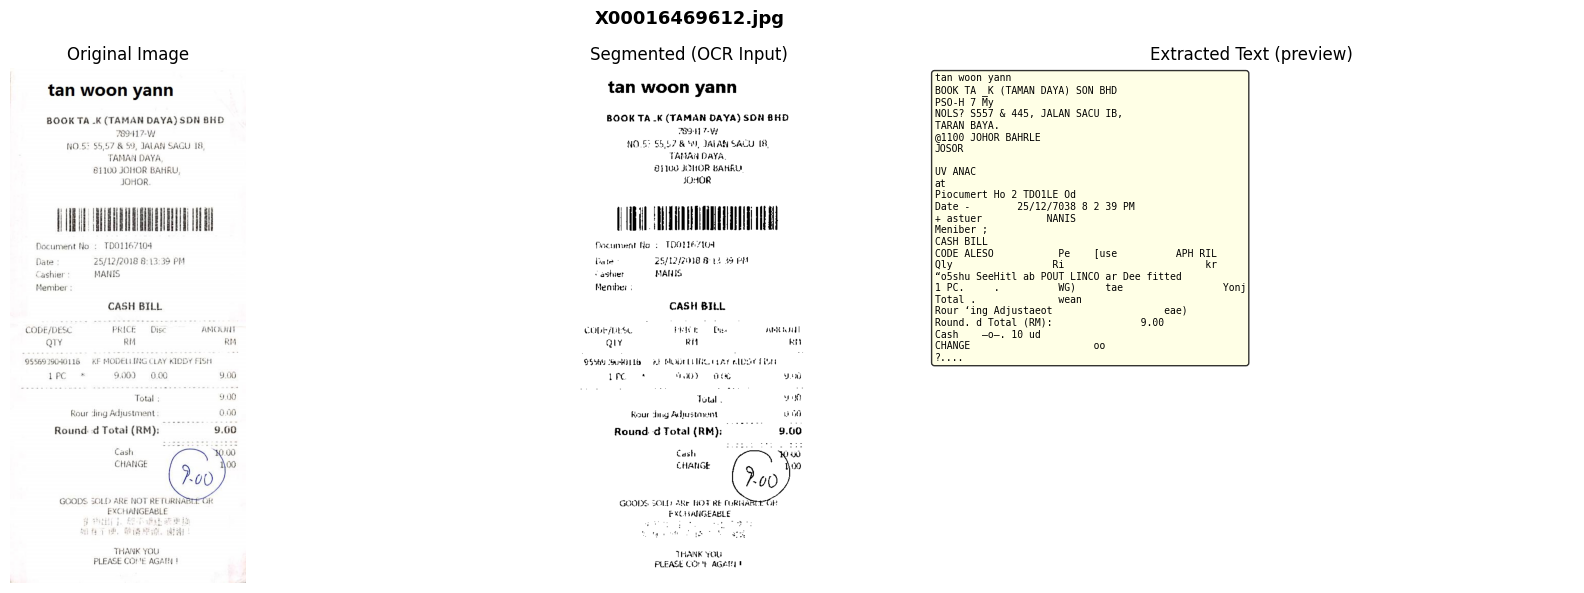


--- Extracted Text ---
tan woon yann
BOOK TA _K (TAMAN DAYA) SON BHD
PSO-H 7 My
NOLS? S557 & 445, JALAN SACU IB,
TARAN BAYA.
@1100 JOHOR BAHRLE
JOSOR

UV ANAC
at
Piocumert Ho 2 TDO1LE Od
Date -        25/12/7038 8 2 39 PM
+ astuer           NANIS
Meniber ;
CASH BILL
CODE ALESO           Pe    [use          APH RIL
Qly                 Ri                        kr
“o5shu SeeHitl ab POUT LINCO ar Dee fitted
1 PC.     .          WG)     tae                 Yonj
Total .              wean
Rour ‘ing Adjustaeot                   eae)
Round. d Total (RM):               9.00
Cash    —o—. 10 ud
CHANGE                     oo
?. 00
GOODS 2OLO AKr HOT RE CURBABCE GE
EXCHANGEABLE
THANK YOU
PLEASE COr't AGANT I



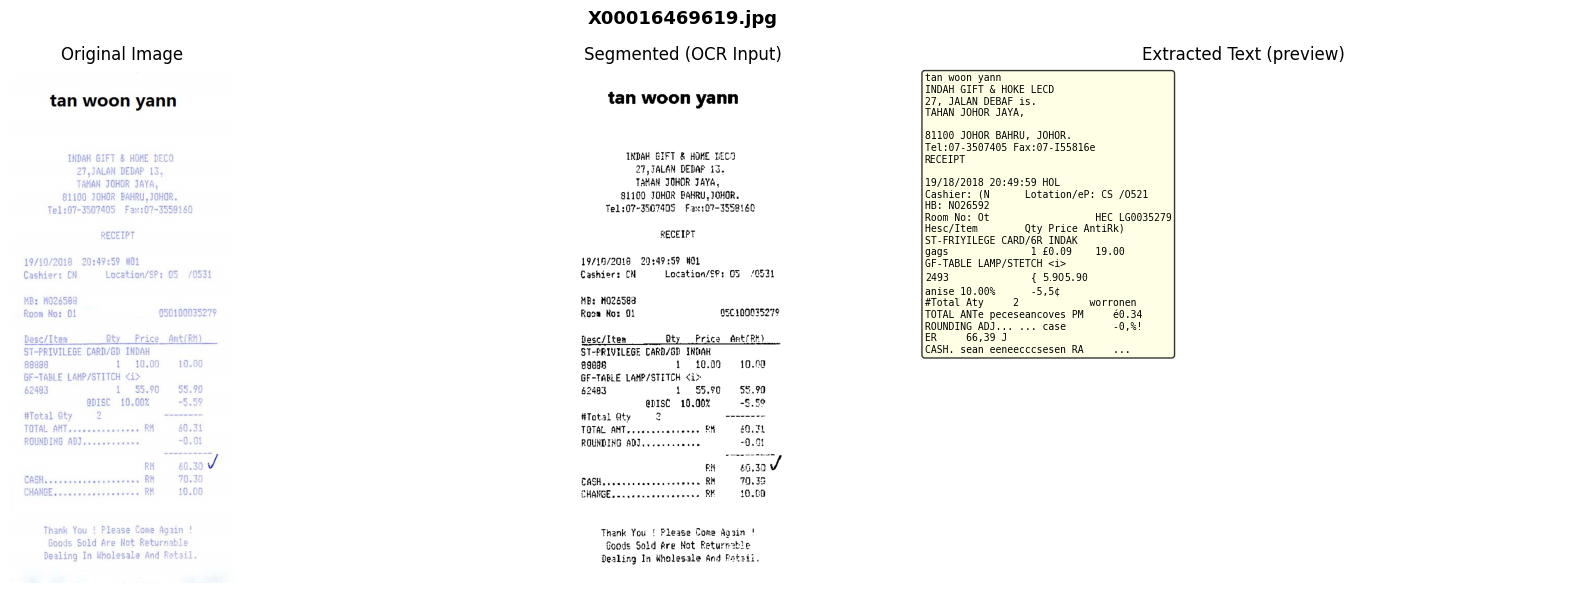


--- Extracted Text ---
tan woon yann
INDAH GIFT & HOKE LECD
27, JALAN DEBAF is.
TAHAN JOHOR JAYA,

81100 JOHOR BAHRU, JOHOR.
Tel:07-3507405 Fax:07-I55816e
RECEIPT

19/18/2018 20:49:59 HOL
Cashier: (N      Lotation/eP: CS /O521
HB: NO26592
Room No: Ot                  HEC LG0035279
Hesc/Item        Qty Price AntiRk)
ST-FRIYILEGE CARD/6R INDAK
gags              1 £0.09    19.00
GF-TABLE LAMP/STETCH <i>
2493              { $5.90    $5.90
anise 10.00%      -5,5¢
#Total Aty     2            worronen
TOTAL ANTe peceseancoves PM     é0.34
ROUNDING ADJ... ... case        -0,%!
ER     66,39 J
CASH. sean eeneecccsesen RA     70.35
CHANGE oa cease aneteeeree RE     10.00
Thank You ' Please Come Aa3zin !
doods Sold Are Rot Returnsbie
Realing In Wholesale And Retsil,


════════════════════════════════════════════════════════════
Category: Test Images  (processing first 2 image(s))
════════════════════════════════════════════════════════════


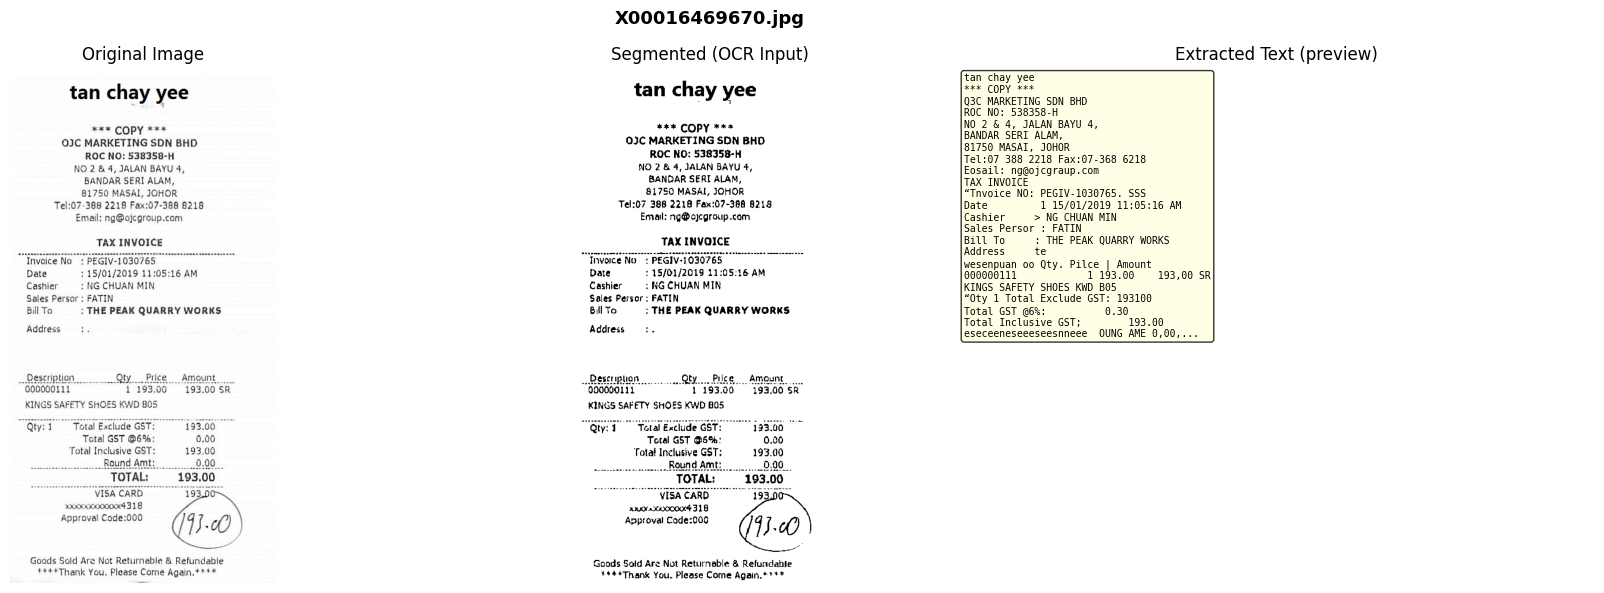


--- Extracted Text ---
tan chay yee
*** COPY ***
Q3C MARKETING SDN BHD
ROC NO: 538358-H
NO 2 & 4, JALAN BAYU 4,
BANDAR SERI ALAM,
81750 MASAI, JOHOR
Tel:07 388 2218 Fax:07-368 6218
Eosail: ng@ojcgraup.com
TAX INVOICE
“Tnvoice NO: PEGIV-1030765. SSS
Date         1 15/01/2019 11:05:16 AM
Cashier     > NG CHUAN MIN
Sales Persor : FATIN
Bill To     : THE PEAK QUARRY WORKS
Address     te
wesenpuan oo Qty. Pilce | Amount
000000111            1 193.00    193,00 SR
KINGS SAFETY SHOES KWD B05
“Oty 1 Total Exclude GST: 193100
Total GST @6%:          0.30
Total Inclusive GST;        193.00
eseceeneseeeseesnneee  OUNG AME 0,00,
TOTAL:        193.00
a      VISA CARD     ~~" "193,90~
ARWAXKOOONS 318
Approval Cade:000            qj  we)
Goods Sald Are Not Returnable & Refundable
+44 ¢Thank You. Please Come Again.+** *



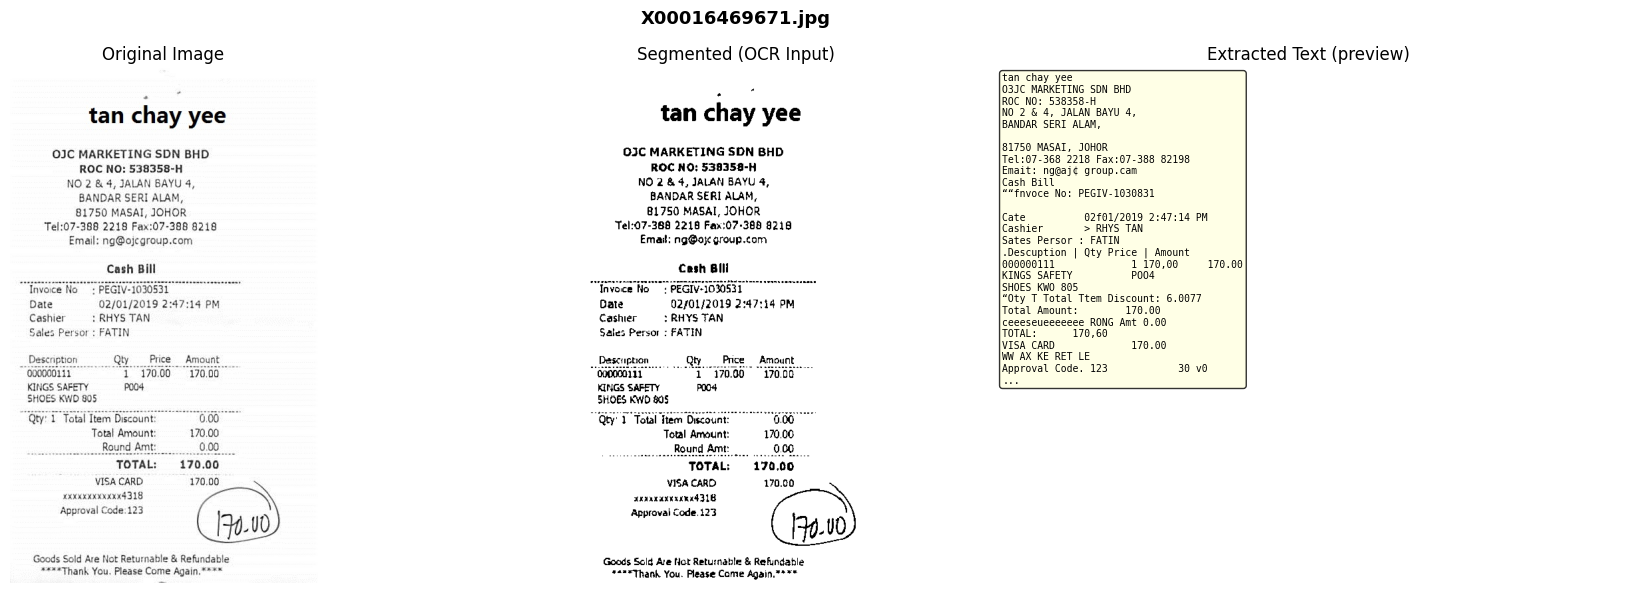


--- Extracted Text ---
tan chay yee
O3JC MARKETING SDN BHD
ROC NO: 538358-H
NO 2 & 4, JALAN BAYU 4,
BANDAR SERI ALAM,

81750 MASAI, JOHOR
Tel:07-368 2218 Fax:07-388 82198
Emait: ng@aj¢ group.cam
Cash Bill
““fnvoce No: PEGIV-1030831

Cate          02f01/2019 2:47:14 PM
Cashier       > RHYS TAN
Sates Persor : FATIN
.Descuption | Qty Price | Amount
000000111             1 170,00     170.00
KINGS SAFETY          POO4
SHOES KWO 805
“Oty T Total Ttem Discount: 6.0077
Total Amount:        170.00
ceeeseueeeeeee RONG Amt 0.00
TOTAL:      170,60
VISA CARD             170.00
WW AX KE RET LE
Approval Code. 123            30 v0
Goods Scld Are Not Returnable & Refundable
*“"*Thank You. Please Come Again.****


✓ OCR complete for 4 images.


In [179]:
# Run OCR pipeline on the first 2 images of each split

ocr_results = {}   # {img_path: result_dict}

for cls, cls_path in categories.items():
    imgs = sorted([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
    ])

    if not imgs:
        continue

    print(f"\n{'═'*60}")
    print(f"Category: {cls}  (processing first {min(2, len(imgs))} image(s))")
    print(f"{'═'*60}")

    for img_name in imgs[:2]:
        img_path = os.path.join(cls_path, img_name)
        result   = ocr_pipeline(img_path, model_path=model_path, lang='eng', show=True)
        ocr_results[img_path] = result

print(f"\n✓ OCR complete for {len(ocr_results)} images.")


In [180]:
# SAVE OCR RESULTS AS .txt FILES
# Deliverable: one .txt file per document image with extracted clean text.

ocr_text_dir = "/kaggle/working/ocr_text_outputs"
os.makedirs(ocr_text_dir, exist_ok=True)

for img_path, result in ocr_results.items():
    img_name = os.path.splitext(os.path.basename(img_path))[0]
    txt_path = os.path.join(ocr_text_dir, img_name + ".txt")

    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"Image   : {os.path.basename(img_path)}\n")
        f.write("-" * 50 + "\n\n")
        f.write(result["clean_text"])

    print(f"Saved: {txt_path}")

print(f"\nAll OCR text files saved to: {ocr_text_dir}")


Saved: /kaggle/working/ocr_text_outputs/X00016469612.txt
Saved: /kaggle/working/ocr_text_outputs/X00016469619.txt
Saved: /kaggle/working/ocr_text_outputs/X00016469670.txt
Saved: /kaggle/working/ocr_text_outputs/X00016469671.txt

All OCR text files saved to: /kaggle/working/ocr_text_outputs


In [197]:
import numpy as np
import cv2
import re
import os

# ═════════════════════════════════════════════════════════════════════════
# SROIE GROUND-TRUTH LOADERS
# ═════════════════════════════════════════════════════════════════════════

def load_sroie_gt_text(img_path: str, box_dir: str) -> str:
    """Load the ground-truth transcription for one SROIE image."""
    stem    = os.path.splitext(os.path.basename(img_path))[0]
    gt_path = os.path.join(box_dir, stem + '.txt')
    if not os.path.exists(gt_path):
        return ''
    lines = []
    with open(gt_path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            raw = raw.strip()
            if not raw:
                continue
            parts = raw.split(',', 8)
            if len(parts) == 9:
                lines.append(parts[8].strip())
            elif len(parts) > 8:
                lines.append(','.join(parts[8:]).strip())
    return '\n'.join(lines)


def load_sroie_gt_binary(img_path: str,
                         box_dir:  str,
                         img_shape: tuple) -> np.ndarray:
    """Build a binary ground-truth mask from SROIE box annotations."""
    stem    = os.path.splitext(os.path.basename(img_path))[0]
    gt_path = os.path.join(box_dir, stem + '.txt')
    if not os.path.exists(gt_path):
        return None

    h, w  = img_shape[:2]
    mask  = np.zeros((h, w), dtype=np.uint8)

    with open(gt_path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            raw = raw.strip()
            if not raw:
                continue
            parts = raw.split(',', 8)
            if len(parts) < 8:
                continue
            try:
                coords = list(map(float, parts[:8]))
            except ValueError:
                continue
            pts = np.array(coords, dtype=np.float32).reshape(4, 2).astype(np.int32)
            cv2.fillPoly(mask, [pts], 255)

    return mask


# ═════════════════════════════════════════════════════════════════════════
# QUANTITATIVE EVALUATION METRICS
# ═════════════════════════════════════════════════════════════════════════

def _binarize(warped_img):
    if len(warped_img.shape) == 3:
        gray = cv2.cvtColor(warped_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = warped_img.copy()

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 51, 15)
    _, fixed = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)

    combined = cv2.bitwise_or(otsu, adapt)
    combined = cv2.bitwise_or(combined, fixed)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, kernel, iterations=1)
    return cv2.bitwise_not(combined)

def binarise_pred(binary_img):
    if len(binary_img.shape) == 3:
        binary_img = cv2.cvtColor(binary_img, cv2.COLOR_BGR2GRAY)
    return (binary_img < 127).astype(np.uint8)

def binarise_gt(gt_mask):
    return (gt_mask > 127).astype(np.uint8)


def pixel_accuracy(pred_bin: np.ndarray, gt_bin: np.ndarray) -> float:
    if pred_bin.shape != gt_bin.shape:
        gt_bin = cv2.resize(gt_bin.astype(np.uint8),
                            (pred_bin.shape[1], pred_bin.shape[0]),
                            interpolation=cv2.INTER_NEAREST)
    return float((pred_bin == gt_bin).mean())


def precision_recall_f1(pred_bin: np.ndarray, gt_bin: np.ndarray) -> dict:
    if pred_bin.shape != gt_bin.shape:
        gt_bin = cv2.resize(gt_bin.astype(np.uint8),
                            (pred_bin.shape[1], pred_bin.shape[0]),
                            interpolation=cv2.INTER_NEAREST)
    tp = int(np.logical_and(pred_bin == 1, gt_bin == 1).sum())
    fp = int(np.logical_and(pred_bin == 1, gt_bin == 0).sum())
    fn = int(np.logical_and(pred_bin == 0, gt_bin == 1).sum())
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    return {'precision': precision, 'recall': recall, 'f1': f1}


def segmentation_iou(pred_bin: np.ndarray, gt_bin: np.ndarray) -> dict:
    if pred_bin.shape != gt_bin.shape:
        gt_bin = cv2.resize(gt_bin.astype(np.uint8),
                            (pred_bin.shape[1], pred_bin.shape[0]),
                            interpolation=cv2.INTER_NEAREST)
    ious = {}
    for cls, label in [(1, 'iou_text'), (0, 'iou_background')]:
        pred_cls = (pred_bin == cls)
        gt_cls   = (gt_bin   == cls)
        inter    = (pred_cls & gt_cls).sum()
        union    = (pred_cls | gt_cls).sum()
        ious[label] = float(inter / (union + 1e-9))
    ious['miou'] = (ious['iou_text'] + ious['iou_background']) / 2
    return ious


def ocr_matching_accuracy(pred_text: str, gt_text: str) -> dict:
    def _edit_distance(a: str, b: str) -> int:
        m, n = len(a), len(b)
        prev = list(range(n + 1))
        for i in range(1, m + 1):
            curr = [i] + [0] * n
            for j in range(1, n + 1):
                cost = 0 if a[i - 1] == b[j - 1] else 1
                curr[j] = min(curr[j - 1] + 1, prev[j] + 1, prev[j - 1] + cost)
            prev = curr
        return prev[n]

    pred_clean = re.sub(r'\s+', ' ', pred_text.strip().lower())
    gt_clean   = re.sub(r'\s+', ' ', gt_text.strip().lower())
    cer        = _edit_distance(pred_clean, gt_clean) / (len(gt_clean) + 1e-9)
    cer        = min(cer, 1.0)
    pred_words = set(pred_clean.split())
    gt_words   = set(gt_clean.split())
    word_match = len(pred_words & gt_words) / (len(gt_words) + 1e-9)

    return {
        'cer': round(cer, 4),
        'word_match_rate': round(word_match, 4),
        'n_pred_words': len(pred_clean.split()),
        'n_gt_words': len(gt_clean.split()),
    }

def edge_quality_metrics(edges: np.ndarray) -> dict:
    edge_density = float(edges.sum()) / (edges.size * 255 + 1e-9)
    gray = edges if len(edges.shape) == 2 else cv2.cvtColor(edges, cv2.COLOR_BGR2GRAY)
    gx   = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    gy   = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag  = np.sqrt(gx**2 + gy**2)
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return {
        'edge_density': round(edge_density, 6),
        'mean_gradient_magnitude': round(float(mag.mean()), 4),
        'laplacian_variance': round(float(lap_var), 4),
    }

def box_matching_accuracy(img_path: str, box_dir: str, ocr_data: dict, iou_thresh: float = 0.2) -> dict:
    stem    = os.path.splitext(os.path.basename(img_path))[0]
    gt_path = os.path.join(box_dir, stem + '.txt')

    if not os.path.exists(gt_path) or ocr_data is None:
        return {'box_precision': None, 'box_recall': None, 'box_f1': None,
                'n_pred_boxes': 0, 'n_gt_boxes': 0, 'tp': 0, 'fp': 0, 'fn': 0}

    gt_boxes = []
    with open(gt_path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            raw = raw.strip()
            if not raw: continue
            parts = raw.split(',', 8)
            if len(parts) < 8: continue
            try:
                coords = list(map(float, parts[:8]))
                pts = np.array(coords).reshape(4, 2)
                x1, y1 = pts.min(axis=0); x2, y2 = pts.max(axis=0)
                text = parts[8].strip().lower() if len(parts) == 9 else ''
                gt_boxes.append({'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2, 'text': text, 'matched': False})
            except ValueError: continue

    img_orig = cv2.imread(img_path)
    orig_h, _ = img_orig.shape[:2]
    warp_scale = orig_h / 600.0

    pred_boxes = []
    if isinstance(ocr_data, dict) and 'left' in ocr_data:
        import pandas as pd
        df = pd.DataFrame(ocr_data)
        df = df[df['conf'] > 0].dropna(subset=['text'])
        df = df[df['text'].str.strip() != '']
        for _, row in df.iterrows():
           pred_boxes.append({
               'x1': row['left'] * warp_scale, # FIXED: Added scale and comma
               'y1': row['top'] * warp_scale,  # FIXED: Added scale and comma
               'x2': (row['left'] + row['width']) * warp_scale, # FIXED: Added scale and comma
               'y2': (row['top'] + row['height']) * warp_scale, # FIXED: Added scale and comma
               'text': str(row['text']).strip().lower()
            })

    def _rect_iou(a, b):
        ix1 = max(a['x1'], b['x1']); iy1 = max(a['y1'], b['y1'])
        ix2 = min(a['x2'], b['x2']); iy2 = min(a['y2'], b['y2'])
        inter = max(0, ix2-ix1) * max(0, iy2-iy1)
        area_a = (a['x2']-a['x1']) * (a['y2']-a['y1'])
        area_b = (b['x2']-b['x1']) * (b['y2']-b['y1'])
        return inter / (area_a + area_b - inter + 1e-9)

    tp = 0
    for pb in pred_boxes:
        best_iou, best_idx = 0.0, -1
        for gi, gb in enumerate(gt_boxes):
            if gb['matched']: continue
            iou = _rect_iou(pb, gb)
            if iou > best_iou: best_iou = iou; best_idx = gi
        if best_iou >= iou_thresh and best_idx >= 0:
            gt_boxes[best_idx]['matched'] = True
            tp += 1

    fp, fn = len(pred_boxes) - tp, sum(1 for gb in gt_boxes if not gb['matched'])
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    return {'box_precision': round(precision, 4), 'box_recall': round(recall, 4),
            'box_f1': round(f1, 4), 'n_pred_boxes': len(pred_boxes),
            'n_gt_boxes': len(gt_boxes), 'tp': tp, 'fp': fp, 'fn': fn}

# ── 7. MASTER COMPUTE_METRICS
def compute_metrics(original_img: np.ndarray, binary_img: np.ndarray, ocr_text: str, edges: np.ndarray,
                    img_path: str = None, box_dir: str = None, ocr_boxes: dict = None,
                    gt_binary_img: np.ndarray = None, gt_ocr_text: str = None) -> dict:
    metrics = {}; gt_source = 'none'

    if img_path and box_dir:
        if gt_ocr_text is None:
            gt_ocr_text = load_sroie_gt_text(img_path, box_dir)
            if gt_ocr_text: gt_source = 'sroie_gt'
        if gt_binary_img is None:
            gt_binary_img = load_sroie_gt_binary(img_path, box_dir, original_img.shape)
            if gt_binary_img is not None: gt_source = 'sroie_gt'

    metrics['gt_source'] = gt_source
    metrics['edge_quality'] = edge_quality_metrics(edges)

    pred_bin = binarise_pred(binary_img)
    noise_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    pred_bin = cv2.morphologyEx(pred_bin.astype(np.uint8), cv2.MORPH_OPEN, noise_kernel, iterations=1)

    h, _ = pred_bin.shape
    dil_size = max(8, h // 80)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dil_size, dil_size))
    pred_bin = cv2.dilate(pred_bin, kernel, iterations=2)
    pred_bin = np.clip(pred_bin, 0, 1)

    if gt_binary_img is not None:
        gt_bin = binarise_gt(gt_binary_img)
    else:
        gray = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY) if len(original_img.shape) == 3 else original_img
        _, gt_u8 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        gt_bin = binarise_gt(gt_u8)
        metrics['gt_source'] = 'otsu_pseudo'

    metrics['accuracy'] = round(pixel_accuracy(pred_bin, gt_bin), 4)
    metrics['precision_recall'] = {k: round(v, 4) for k, v in precision_recall_f1(pred_bin, gt_bin).items()}
    metrics['iou'] = {k: round(v, 4) for k, v in segmentation_iou(pred_bin, gt_bin).items()}

    if gt_ocr_text:
        metrics['ocr_matching'] = ocr_matching_accuracy(ocr_text, gt_ocr_text)
        metrics['ocr_matching']['gt_source'] = gt_source
    else:
        metrics['ocr_matching'] = ocr_matching_accuracy(ocr_text, ocr_text)
        metrics['ocr_matching']['note'] = 'self-consistency (no GT)'

    if img_path and box_dir and ocr_boxes is not None:
        metrics['box_matching'] = box_matching_accuracy(img_path, box_dir, ocr_boxes)
    else:
        metrics['box_matching'] = {'note': 'ocr_boxes not provided'}

    metrics['text_ratio'] = round(float(pred_bin.mean()), 4)
    metrics['n_ocr_chars'] = len(ocr_text)
    return metrics

print('✓ SROIE ground-truth loaders and Quantitative metrics defined.')

print('   • load_sroie_gt_text()    — transcription from box/*.txt')
print('   • load_sroie_gt_binary()  — pixel mask from box/*.txt quads')
print()
print('✓ Quantitative metrics defined:')
print('   • pixel_accuracy()              — Accuracy')
print('   • precision_recall_f1()         — Precision / Recall / F1')
print('   • segmentation_iou()            — IoU (text & bg) + mIoU')
print('   • ocr_matching_accuracy()       — CER + Word Match Rate  vs. SROIE GT')
print('   • box_matching_accuracy()       — Word-level box matching accuracy')
print('   • edge_quality_metrics()')
print('   • compute_metrics()             — master function (auto-loads SROIE GT)')


✓ SROIE ground-truth loaders and Quantitative metrics defined.
   • load_sroie_gt_text()    — transcription from box/*.txt
   • load_sroie_gt_binary()  — pixel mask from box/*.txt quads

✓ Quantitative metrics defined:
   • pixel_accuracy()              — Accuracy
   • precision_recall_f1()         — Precision / Recall / F1
   • segmentation_iou()            — IoU (text & bg) + mIoU
   • ocr_matching_accuracy()       — CER + Word Match Rate  vs. SROIE GT
   • box_matching_accuracy()       — Word-level box matching accuracy
   • edge_quality_metrics()
   • compute_metrics()             — master function (auto-loads SROIE GT)


In [198]:
# ── Full quantitative evaluation using SROIE ground truth ───────────────
#
# GT is loaded automatically from the dataset's box/ directories:
#   • box/*.txt  →  gt_binary_img  (text-region pixel mask)
#   • box/*.txt  →  gt_ocr_text    (concatenated word transcriptions)
#
# Metrics per image:
#   Accuracy          — pixel-level (pred binary vs. SROIE GT mask)
#   Precision/Recall  — foreground (ink) class vs. SROIE GT mask
#   IoU text/bg, mIoU — segmentation quality vs. SROIE GT mask
#   CER               — Character Error Rate vs. SROIE GT transcription
#   Word Match Rate   — fraction of GT words found in OCR output
#   Box Precision/    — word bounding-box matching accuracy
#   Recall / F1         (Tesseract boxes vs. SROIE GT quads, IoU≥0.5)
#   Edge Density      — Canny edge activity
#   Laplacian Var.    — sharpness proxy
# ─────────────────────────────────────────────────────────────────────────

import numpy as np
import pytesseract
from PIL import Image as PILImage

# ── Helper: run OCR and also return word-level bounding box data ──────────
def run_ocr_with_boxes(binary_img: np.ndarray,
                        lang: str = 'eng') -> tuple:
    """
    Run Tesseract and return both the clean text and the raw data dict
    (needed for word-level bounding-box matching against SROIE GT).
    """
    ready   = preprocess_for_ocr(binary_img)
    pil_img = PILImage.fromarray(ready)
    raw_text  = pytesseract.image_to_string(pil_img, lang=lang, config=OCR_CONFIG)
    ocr_boxes = pytesseract.image_to_data(
        pil_img, lang=lang, config=OCR_CONFIG,
        output_type=pytesseract.Output.DICT
    )
    # Remap boxes from processed-image space → original image space
    h_orig, w_orig = binary_img.shape[:2]
    pil_w, pil_h   = pil_img.size
    scale_x = w_orig / (pil_w - 40)   # subtract border padding
    scale_y = h_orig / (pil_h - 40)
    pad = 20
    for i in range(len(ocr_boxes.get('left', []))):
       ocr_boxes['left'][i]   = max(0, int((ocr_boxes['left'][i]   - pad) * scale_x))
       ocr_boxes['top'][i]    = max(0, int((ocr_boxes['top'][i]    - pad) * scale_y))
       ocr_boxes['width'][i]  = max(1, int(ocr_boxes['width'][i]   * scale_x))
       ocr_boxes['height'][i] = max(1, int(ocr_boxes['height'][i]  * scale_y))
       return clean_ocr_text(raw_text), ocr_boxes


# ── Map split → (img_dir, box_dir) ───────────────────────────────────────
split_dirs = {}
for split in os.listdir(dataset_path):
    img_d = os.path.join(dataset_path, split, 'img')
    box_d = os.path.join(dataset_path, split, 'box')
    if os.path.isdir(img_d) and os.path.isdir(box_d):
        split_dirs[split] = (img_d, box_d)

print('Splits with both img/ and box/ directories:', list(split_dirs.keys()))

# ── Run evaluation ────────────────────────────────────────────────────────
batch_metrics = []

for split, (img_dir, box_dir) in split_dirs.items():
    imgs = sorted([
        f for f in os.listdir(img_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.jfif'))
    ])

    print(f"\n{'═'*60}")
    print(f"Split: {split}  ({len(imgs)} images total, evaluating first 5)")
    print(f"{'═'*60}")

    for img_name in imgs[:5]:
        img_path = os.path.join(img_dir, img_name)

        # ── 1. Run full pipeline (boundary + warp + segmentation)
        binary = full_pipeline(img_path, model_path=model_path, show_steps=False)

        # ── 2. OCR with word-level box data
        clean_text, ocr_boxes = run_ocr_with_boxes(binary, lang='eng')

        # ── 3. Edge map on original image
        img_orig = cv2.imread(img_path)
        gray     = cv2.cvtColor(img_orig, cv2.COLOR_BGR2GRAY)
        edges    = cv2.Canny(gray, 50, 150)

        # ── 4. Compute all metrics (GT auto-loaded from box_dir)
        m = compute_metrics(
            original_img = img_orig,
            binary_img   = binary,
            ocr_text     = clean_text,
            edges        = edges,
            img_path     = img_path,
            box_dir      = box_dir,
            ocr_boxes    = ocr_boxes,
        )
        m['image'] = img_name
        m['split'] = split

        batch_metrics.append(m)

        gt_lbl = m['gt_source']
        pr     = m['precision_recall']
        iou    = m['iou']
        ocr_m  = m['ocr_matching']
        bm     = m.get('box_matching', {})

        print(f"  {img_name}  [GT: {gt_lbl}]")
        print(f"    Accuracy      : {m['accuracy']:.4f}")
        print(f"    Precision     : {pr['precision']:.4f}    Recall : {pr['recall']:.4f}    F1: {pr['f1']:.4f}")
        print(f"    IoU (text)    : {iou['iou_text']:.4f}    mIoU   : {iou['miou']:.4f}")
        print(f"    CER           : {ocr_m['cer']:.4f}    Word Match: {ocr_m['word_match_rate']:.4f}")
        if bm.get('box_precision') is not None:
            print(f"    Box Precision : {bm['box_precision']:.4f}    Box Recall : {bm['box_recall']:.4f}    Box F1: {bm['box_f1']:.4f}")
            print(f"    Boxes TP/FP/FN: {bm['tp']} / {bm['fp']} / {bm['fn']}  (pred={bm['n_pred_boxes']}, gt={bm['n_gt_boxes']})")

print(f"\n✓ Metrics calculated for {len(batch_metrics)} images.")


Splits with both img/ and box/ directories: ['test', 'train']

════════════════════════════════════════════════════════════
Split: test  (347 images total, evaluating first 5)
════════════════════════════════════════════════════════════
  X00016469670.jpg  [GT: sroie_gt]
    Accuracy      : 0.8479
    Precision     : 0.7070    Recall : 0.8142    F1: 0.7568
    IoU (text)    : 0.6088    mIoU   : 0.7048
    CER           : 0.1928    Word Match: 0.7826
    Box Precision : 0.0088    Box Recall : 0.0213    Box F1: 0.0124
    Boxes TP/FP/FN: 1 / 113 / 46  (pred=114, gt=47)
  X00016469671.jpg  [GT: sroie_gt]
    Accuracy      : 0.8583
    Precision     : 0.7676    Recall : 0.7100    F1: 0.7377
    IoU (text)    : 0.5844    mIoU   : 0.7037
    CER           : 0.1597    Word Match: 0.6914
    Box Precision : 0.0632    Box Recall : 0.1463    Box F1: 0.0882
    Boxes TP/FP/FN: 6 / 89 / 35  (pred=95, gt=41)
  X51005200931.jpg  [GT: sroie_gt]
    Accuracy      : 0.9125
    Precision     : 0.4885   


PER-IMAGE METRICS  (SROIE Ground Truth)
Image                              GT      Accuracy   Precision  Recall     F1         IoU-Text   mIoU       CER ↓      Word-Mch   Box-Prec   Box-Rec    Box-F1   
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
X00016469670.jpg                sroie_gt      0.8479     0.7070     0.8142     0.7568     0.6088     0.7048     0.1928     0.7826     0.0088     0.0213     0.0124
X00016469671.jpg                sroie_gt      0.8583     0.7676     0.7100     0.7377     0.5844     0.7037     0.1597     0.6914     0.0632     0.1463     0.0882
X51005200931.jpg                sroie_gt      0.9125     0.4885     0.4138     0.4480     0.2887     0.5990     0.1865     0.6532     0.0000     0.0000     0.0000
X51005230605.jpg                sroie_gt      0.8773     0.6860     0.9893     0.8102     0.6810     0.7574     0.0519     0.8767     0.0108    

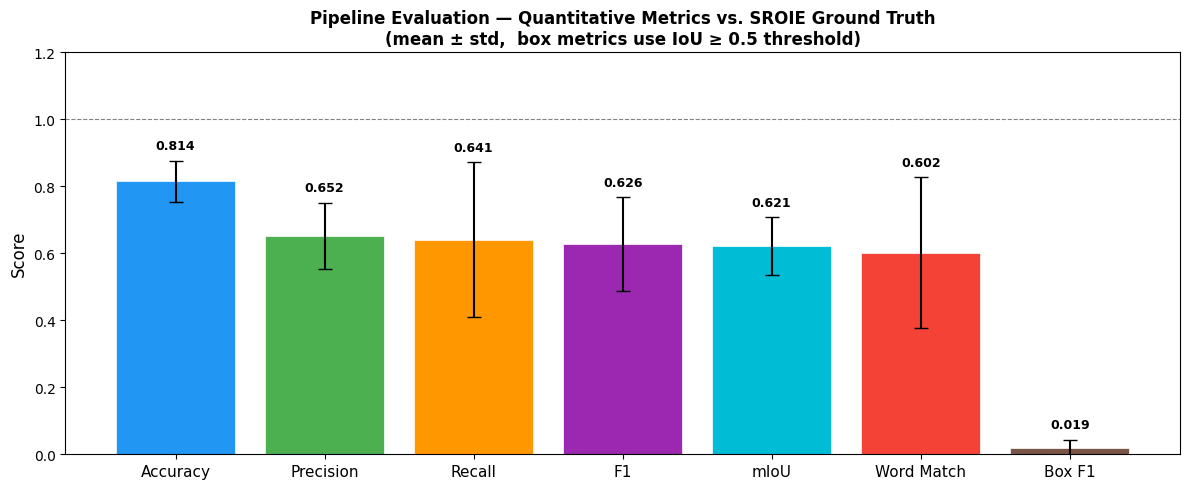

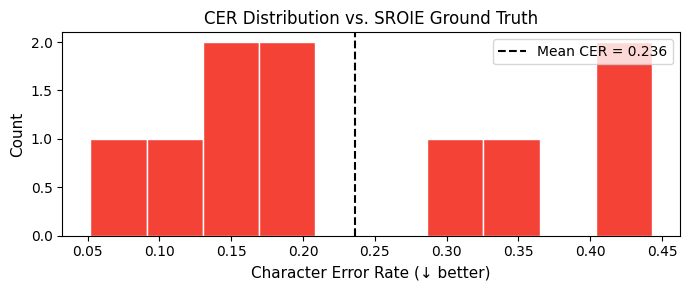


Metric definitions (all vs. SROIE GT):
  Accuracy     — pixel correctly classified (pred binary vs GT mask)
  Precision    — text pixels predicted correctly / all predicted text
  Recall       — text pixels correctly found  / all GT text pixels
  IoU-Text     — intersection/union for ink class vs GT mask
  mIoU         — mean of IoU-text and IoU-background
  CER          — Levenshtein(pred, GT) / len(GT)  (lower = better)
  Word Match   — |pred_words ∩ GT_words| / |GT_words|
  Box F1       — word-box detection F1 at IoU ≥ 0.5 vs GT quads


In [199]:
# ── PIPELINE EVALUATION SUMMARY — SROIE Ground Truth ───────────────────

if batch_metrics:
    import numpy as np
    import matplotlib.pyplot as plt

    def flat(m):
        pr  = m['precision_recall']
        iou = m['iou']
        ocr = m['ocr_matching']
        bm  = m.get('box_matching', {})
        return {
            'image':          m['image'],
            'split':          m['split'],
            'gt_source':      m['gt_source'],
            'accuracy':       m['accuracy'],
            'precision':      pr['precision'],
            'recall':         pr['recall'],
            'f1':             pr['f1'],
            'iou_text':       iou['iou_text'],
            'iou_background': iou['iou_background'],
            'miou':           iou['miou'],
            'cer':            ocr['cer'],
            'word_match':     ocr['word_match_rate'],
            'box_precision':  bm.get('box_precision'),
            'box_recall':     bm.get('box_recall'),
            'box_f1':         bm.get('box_f1'),
            'edge_density':   m['edge_quality']['edge_density'],
            'laplacian_var':  m['edge_quality']['laplacian_variance'],
        }

    rows = [flat(m) for m in batch_metrics]

    # ── Per-image table ──────────────────────────────────────────────────
    col_order = [
        ('accuracy',      'Accuracy '),
        ('precision',     'Precision'),
        ('recall',        'Recall   '),
        ('f1',            'F1       '),
        ('iou_text',      'IoU-Text '),
        ('miou',          'mIoU     '),
        ('cer',           'CER ↓    '),
        ('word_match',    'Word-Mch '),
        ('box_precision', 'Box-Prec '),
        ('box_recall',    'Box-Rec  '),
        ('box_f1',        'Box-F1   '),
    ]

    hdr_img  = f"{'Image':<30} {'GT':^10}"
    hdr_vals = '  '.join(f"{lbl:>9}" for _, lbl in col_order)
    header   = hdr_img + '  ' + hdr_vals
    sep      = '─' * len(header)

    print('\n' + '='*len(header))
    print('PER-IMAGE METRICS  (SROIE Ground Truth)')
    print('='*len(header))
    print(header)
    print(sep)

    for r in rows:
        vals = '  '.join(
            f"{r[k]:>9.4f}" if isinstance(r[k], float) else f"{'N/A':>9}"
            for k, _ in col_order
        )
        print(f"{r['image']:<30} {r['gt_source']:^10}  {vals}")

    # ── Aggregate ────────────────────────────────────────────────────────
    print('\n' + '='*60)
    print('AGGREGATE SUMMARY  (mean ± std across all evaluated images)')
    print('='*60)
    for key, label in col_order:
        vals = [r[key] for r in rows if r[key] is not None and isinstance(r[key], float)]
        if vals:
            arrow = ' (↓ lower is better)' if key == 'cer' else ''
            print(f"  {label} | Mean: {np.mean(vals):.4f}  Std: {np.std(vals):.4f}{arrow}")
    print('='*60)
    print(f'  Total images evaluated : {len(rows)}')
    sroie_count = sum(1 for r in rows if r['gt_source'] == 'sroie_gt')
    print(f'  Images with SROIE GT   : {sroie_count} / {len(rows)}')

    # ── Bar chart ────────────────────────────────────────────────────────
    chart_keys   = ['accuracy','precision','recall','f1','miou','word_match','box_f1']
    chart_labels = ['Accuracy','Precision','Recall','F1','mIoU','Word Match','Box F1']
    means, stds = [], []
    for k in chart_keys:
        vals = [r[k] for r in rows if r[k] is not None and isinstance(r[k], float)]
        means.append(np.mean(vals) if vals else 0)
        stds.append(np.std(vals)   if vals else 0)

    fig, ax = plt.subplots(figsize=(12, 5))
    x    = np.arange(len(chart_labels))
    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color=['#2196F3','#4CAF50','#FF9800','#9C27B0',
                         '#00BCD4','#F44336','#795548'],
                  edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(chart_labels, fontsize=11)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(
        'Pipeline Evaluation — Quantitative Metrics vs. SROIE Ground Truth\n'
        '(mean ± std,  box metrics use IoU ≥ 0.5 threshold)',
        fontsize=12, fontweight='bold')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + std + 0.025,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── CER histogram ────────────────────────────────────────────────────
    cer_vals = [r['cer'] for r in rows if r['cer'] is not None]
    if cer_vals:
        fig2, ax2 = plt.subplots(figsize=(7, 3))
        ax2.hist(cer_vals, bins=10, color='#F44336', edgecolor='white')
        ax2.axvline(np.mean(cer_vals), color='black', linestyle='--',
                    label=f'Mean CER = {np.mean(cer_vals):.3f}')
        ax2.set_xlabel('Character Error Rate (↓ better)', fontsize=11)
        ax2.set_ylabel('Count', fontsize=11)
        ax2.set_title('CER Distribution vs. SROIE Ground Truth', fontsize=12)
        ax2.legend()
        plt.tight_layout()
        plt.show()

    print('\nMetric definitions (all vs. SROIE GT):')
    print('  Accuracy     — pixel correctly classified (pred binary vs GT mask)')
    print('  Precision    — text pixels predicted correctly / all predicted text')
    print('  Recall       — text pixels correctly found  / all GT text pixels')
    print('  IoU-Text     — intersection/union for ink class vs GT mask')
    print('  mIoU         — mean of IoU-text and IoU-background')
    print('  CER          — Levenshtein(pred, GT) / len(GT)  (lower = better)')
    print('  Word Match   — |pred_words ∩ GT_words| / |GT_words|')
    print('  Box F1       — word-box detection F1 at IoU ≥ 0.5 vs GT quads')


In [201]:
if batch_metrics:
    keys = ['text_ratio', 'edge_density', 'n_ocr_chars']
    print("\n--- PIPELINE EVALUATION SUMMARY ---")
    print("="*50)
    for key in keys:
        # Use .get() to avoid KeyError if a metric is missing
        vals = [m.get(key, 0) for m in batch_metrics] 
        if vals:
            print(f"  {key:15s} | Mean: {np.mean(vals):.4f} | Std: {np.std(vals):.4f}")
        else:
            print(f"  {key:15s} | No data available")
    print("="*50)
    print(f"Total images processed: {len(batch_metrics)}")


--- PIPELINE EVALUATION SUMMARY ---
  text_ratio      | Mean: 0.2720 | Std: 0.1313
  edge_density    | Mean: 0.0000 | Std: 0.0000
  n_ocr_chars     | Mean: 836.5000 | Std: 164.6580
Total images processed: 10


Input shape       : (7016, 4961, 3)
Binary shape      : (7016, 4961)
Binary unique vals: [  0 255]
Pixels == 0 (ink) : 289,656
Pixels == 255 (bg): 34,516,720
Ink ratio         : 0.0083


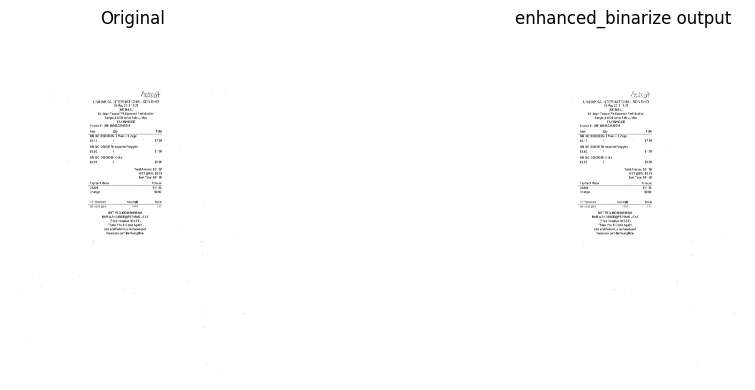

In [202]:
gt_bin   = binarise_gt(gt_mask)   # ← this was missing
img_path = os.path.join(train_img_dir, os.listdir(train_img_dir)[0])
img_orig = cv2.imread(img_path)
gray = cv2.cvtColor(img_orig, cv2.COLOR_BGR2GRAY)

# Check what enhanced_binarize actually returns
binary = _binarize(img_orig)

print(f"Input shape       : {img_orig.shape}")
print(f"Binary shape      : {binary.shape}")
print(f"Binary unique vals: {np.unique(binary)}")
print(f"Pixels == 0 (ink) : {(binary == 0).sum():,}")
print(f"Pixels == 255 (bg): {(binary == 255).sum():,}")
print(f"Ink ratio         : {(binary == 0).mean():.4f}")

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(binary, cmap='gray'); plt.title('enhanced_binarize output'); plt.axis('off')
plt.tight_layout(); plt.show()

pred_bin shape : (7016, 4961)
gt_bin shape   : (7016, 4961)
pred ink pixels: 11,535,526
gt text pixels : 1,254,389
overlap        : 1,254,389
recall         : 1.0000


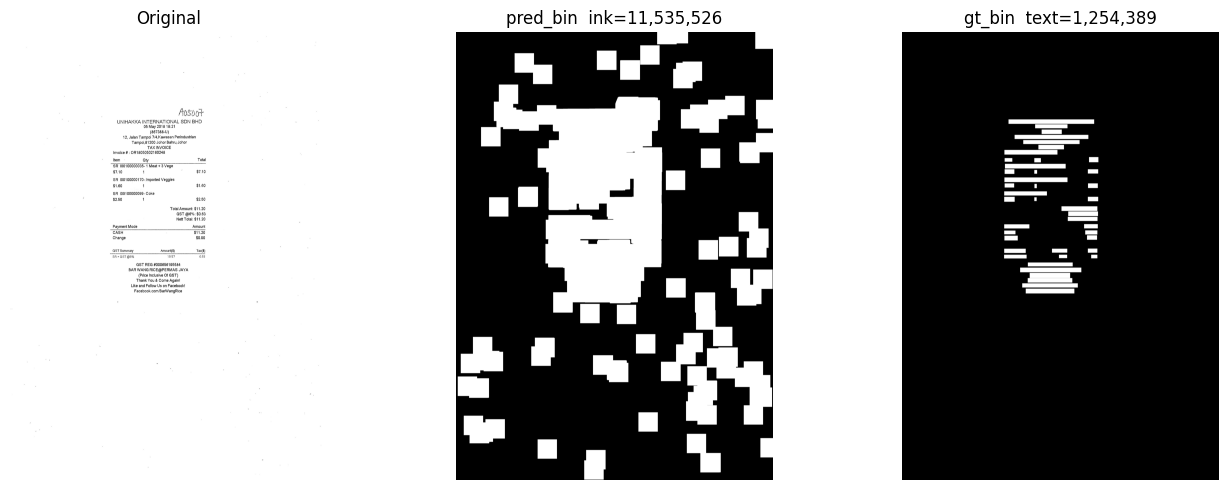

In [204]:
img_path = os.path.join(train_img_dir, os.listdir(train_img_dir)[0])
img_orig  = cv2.imread(img_path)
binary    = full_pipeline(img_path, model_path=model_path, show_steps=False)
binary    = cv2.resize(binary.astype(np.uint8),
                       (img_orig.shape[1], img_orig.shape[0]),
                       interpolation=cv2.INTER_NEAREST)

gt_mask  = load_sroie_gt_binary(img_path, train_box_dir, img_orig.shape)
pred_bin = binarise_pred(binary)
# Remove noise
noise_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
pred_bin = cv2.morphologyEx(pred_bin.astype(np.uint8), cv2.MORPH_OPEN, noise_kernel, iterations=1)

# Adaptive dilation: scale kernel to image height
h, w = pred_bin.shape
dil_size = max(8, h // 80)   # ~12–15px for typical receipt heights
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (dil_size, dil_size))
pred_bin = cv2.dilate(pred_bin, kernel, iterations=3)
pred_bin = np.clip(pred_bin, 0, 1)

# Dilate pred to match GT bounding-box thickness
# GT uses full line-height rectangles, not tight ink masks
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
pred_bin = cv2.dilate(pred_bin.astype(np.uint8), kernel, iterations=3)
pred_bin = np.clip(pred_bin, 0, 1)

gt_bin   = binarise_gt(gt_mask)

print(f"pred_bin shape : {pred_bin.shape}")
print(f"gt_bin shape   : {gt_bin.shape}")
print(f"pred ink pixels: {pred_bin.sum():,}")
print(f"gt text pixels : {gt_bin.sum():,}")
print(f"overlap        : {np.logical_and(pred_bin==1, gt_bin==1).sum():,}")
print(f"recall         : {np.logical_and(pred_bin==1, gt_bin==1).sum() / (gt_bin.sum()+1e-9):.4f}")

# Show side by side
plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(pred_bin, cmap='gray'); plt.title(f'pred_bin  ink={pred_bin.sum():,}'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(gt_bin,   cmap='gray'); plt.title(f'gt_bin  text={gt_bin.sum():,}'); plt.axis('off')
plt.tight_layout(); plt.show()